# 🧠 Pipeline EEG — Predição de Crises Epilépticas
## Notebook 2 — Pré-processamento, Rotulagem, EDA, Features e Modelos Baseline

**Datasets:** CHB-MIT · Siena Scalp EEG · SeizeIT2  
**Autor:** Danilo Pedro da Silva Valério

---

| # | Capítulo | Descrição |
|---|---------|-----------|
| 1 | Instalação & Configurações | Dependências e parâmetros globais |
| 2 | Download | CHB-MIT (S3) · Siena (HTTPS) · SeizeIT2 (S3/OpenNeuro) |
| 3 | Parsers de Anotações | Sumários/Seizure-lists → intervalos de crise em segundos |
| 4 | Carregamento & EDA | Leitura EDF, plots de sinal, PSD, qualidade |
| 5 | Pré-processamento | Notch + Passa-alta + Passa-baixa |
| 6 | Rotulagem Temporal | Interictal / Pré-ictal / Ictal / Pós-ictal |
| 7 | Janelamento | 4 s · 50 % overlap · label majoritário |
| 8 | Salvamento Nível 1 | NPZ por arquivo (sinal filtrado + labels amostra-a-amostra) |
| 9 | Salvamento Nível 2 | NPZ por paciente (janelas + labels de janela) |
| 10 | Extração de Features | Temporal · Espectral · Não-linear |
| 11 | Predição (multiclasse) | LOSO-CV — RF · SVM · XGBoost · votação + métricas por evento |
| 12 | Resultados | Métricas por janela e por evento (sens, FAR, lead time) |

---
# Capítulo 1 — Instalação e Configurações

In [5]:
%pip install mne scipy numpy pandas matplotlib seaborn PyWavelets tqdm boto3 botocore \
             scikit-learn xgboost --quiet
print("✅ Dependências instaladas")

Note: you may need to restart the kernel to use updated packages.
✅ Dependências instaladas



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import os, re, json, warnings, gc, html
import html.parser
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import mne
import pywt
import boto3
from botocore import UNSIGNED
from botocore.config import Config
from scipy.signal  import butter, sosfiltfilt, iirnotch, filtfilt, welch
from scipy.stats   import kurtosis as sp_kurtosis, skew as sp_skew
from tqdm.auto     import tqdm

mne.set_log_level('WARNING')
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
print("✅ Imports OK")

✅ Imports OK


c:\Users\danil\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1.2 Configurações Globais

In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Diretórios ────────────────────────────────────────────────────────────────
ROOT_DIR    = 'data'
CHBMIT_DIR  = os.path.join(ROOT_DIR, 'chb-mit')
SIENA_DIR   = os.path.join(ROOT_DIR, 'siena')
SEIZEIT_DIR = os.path.join(ROOT_DIR, 'seizeit2')
L1_DIR      = os.path.join(ROOT_DIR, 'level1_signals')   # sinal filtrado + labels/amostra
L2_DIR      = os.path.join(ROOT_DIR, 'level2_windows')   # janelas + labels/janela
FEAT_DIR    = os.path.join(ROOT_DIR, 'features')
for d in [CHBMIT_DIR, SIENA_DIR, SEIZEIT_DIR, L1_DIR, L2_DIR, FEAT_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Parâmetros de filtragem ───────────────────────────────────────────────────
F_HP       = 0.5    # Hz  passa-alta
F_LP       = 40.0   # Hz  passa-baixa
F_ORDER    = 4      # ordem Butterworth
NOTCH = {'CHBMIT': 60.0, 'Siena': 50.0, 'SeizeIT2': 50.0}   # rede elétrica por dataset

# ── Janelamento ───────────────────────────────────────────────────────────────
WIN_SEC  = 4      # segundos
OVERLAP  = 0.50   # 50 % de sobreposição

# ── Rotulagem ─────────────────────────────────────────────────────────────────
PRE_SEC   = 10 * 60   # 10 min antes  → pré-ictal
POST_SEC  = 10 * 60   # 10 min depois → pós-ictal
IGAP_SEC  = 10 * 60   # margem de segurança para interictal

# Labels (4 classes + unknown)
LBL = dict(interictal=0, preictal=1, ictal=2, postictal=3, unknown=-1)
LBL_NAMES = {v: k for k, v in LBL.items()}

# ── PACIENTES POR DATASET ─────────────────────────────────────────────────────
# Para o TCC começamos com 1 paciente de cada (teste rápido com o paciente inteiro).
# Para escalar, basta ADICIONAR nomes a estas listas — todo o pipeline abaixo
# percorre estas listas em loop, então nada mais precisa mudar.
PATIENTS = {
    'CHBMIT'  : ["chb01", "chb02", "chb03", "chb04", "chb05"],                 # ex.: ['chb01','chb02','chb03', ...]
    'Siena'   : ["PN00", "PN01", "PN03", "PN05", "PN06"],                  # ex.: ['PN00','PN01', ...]
    'SeizeIT2': ["sub-001", "sub-002", "sub-003", "sub-004", "sub-005"],               # ex.: ['sub-001','sub-002', ...]
}

# Atalho para compatibilidade com células antigas que usavam PILOT[...]
PILOT = {k: v[0] for k, v in PATIENTS.items()}

print("✅ Configurações OK")
for k, v in NOTCH.items(): print(f"   Notch {k:10s}: {v} Hz")
print(f"   Banda       : {F_HP}–{F_LP} Hz")
print(f"   Janela      : {WIN_SEC} s · overlap {int(OVERLAP*100)} %")
print(f"   Pré-ictal   : {PRE_SEC//60} min | Pós-ictal: {POST_SEC//60} min")
for k, v in PATIENTS.items():
    print(f"   Pacientes {k:10s}: {v}")

✅ Configurações OK
   Notch CHBMIT    : 60.0 Hz
   Notch Siena     : 50.0 Hz
   Notch SeizeIT2  : 50.0 Hz
   Banda       : 0.5–40.0 Hz
   Janela      : 4 s · overlap 50 %
   Pré-ictal   : 10 min | Pós-ictal: 10 min
   Pacientes CHBMIT    : ['chb01']
   Pacientes Siena     : ['PN00']
   Pacientes SeizeIT2  : ['sub-001']


---
# Capítulo 2 — Download dos Dados

## 2.1 CHB-MIT via S3 (PhysioNet Open Data)

Bucket `physionet-open`. Baixa apenas os EDFs do paciente piloto listados em `RECORDS-WITH-SEIZURES`.

In [8]:
def s3_client():
    return boto3.client('s3', region_name='us-east-1',
                        config=Config(signature_version=UNSIGNED))

def download_chbmit_patient(patient, local_root=CHBMIT_DIR):
    """
    Baixa, para UM paciente CHB-MIT, apenas os EDFs que contêm crise.
    Usa o índice oficial RECORDS-WITH-SEIZURES para filtrar — não baixa
    arquivos sem crise.
    """
    s3      = s3_client()
    bucket  = 'physionet-open'
    prefix  = 'chbmit/1.0.0/'
    pat_dir = os.path.join(local_root, patient)
    os.makedirs(pat_dir, exist_ok=True)

    # RECORDS-WITH-SEIZURES — lista global de gravações COM crise
    rec_local = os.path.join(local_root, 'RECORDS-WITH-SEIZURES')
    if not os.path.exists(rec_local):
        print("⬇️  Baixando RECORDS-WITH-SEIZURES ...")
        s3.download_file(bucket, prefix + 'RECORDS-WITH-SEIZURES', rec_local)

    with open(rec_local) as f:
        seizure_recs = [l.strip() for l in f if l.strip().startswith(patient + '/')]

    # summary.txt (tem os tempos de início/fim das crises)
    sum_key   = f'{prefix}{patient}/{patient}-summary.txt'
    sum_local = os.path.join(pat_dir, f'{patient}-summary.txt')
    if not os.path.exists(sum_local):
        s3.download_file(bucket, sum_key, sum_local)

    # Baixa SOMENTE os EDFs com crise
    downloaded = 0
    for rec in tqdm(seizure_recs, desc=f'CHB-MIT {patient}', leave=False):
        fname = rec.split('/')[-1]
        local = os.path.join(pat_dir, fname)
        if not os.path.exists(local):
            try:
                s3.download_file(bucket, prefix + rec, local)
                downloaded += 1
            except Exception as e:
                print(f"  ⚠️  {rec}: {e}")
    print(f"✅ CHB-MIT {patient} — {len(seizure_recs)} EDFs com crise | {downloaded} novos")
    return pat_dir

# ── Baixa todos os pacientes CHB-MIT da lista ────────────────────────────────
for _p in PATIENTS['CHBMIT']:
    download_chbmit_patient(_p)

✅ CHB-MIT chb01 — 7 EDFs com crise | 0 novos


## 2.2 Siena via HTTPS (PhysioNet)

In [9]:
SIENA_BASE = 'https://physionet.org/files/siena-scalp-eeg/1.0.0/'

class _LinkParser(html.parser.HTMLParser):
    def __init__(self):
        super().__init__(); self.links = []
    def handle_starttag(self, tag, attrs):
        if tag == 'a':
            for attr, val in attrs:
                if attr == 'href' and not val.startswith(('?','/','..')):
                    self.links.append(val)

def _siena_seizure_edfs(patient, seizures_list_text):
    """Extrai do Seizures-list-PNxx.txt os nomes de EDF que têm crise."""
    edfs = set()
    for line in seizures_list_text.splitlines():
        m = re.search(r'File name:\s*(\S+\.edf)', line, re.IGNORECASE)
        if m:
            edfs.add(m.group(1).strip())
    return edfs

def download_siena_patient(patient, local_root=SIENA_DIR):
    """
    Baixa, para UM paciente Siena: o Seizures-list (anotações) e APENAS os
    EDFs que aparecem nele (ou seja, com crise). Evita baixar gravações sem crise.
    """
    pat_dir  = os.path.join(local_root, patient)
    os.makedirs(pat_dir, exist_ok=True)
    base_url = SIENA_BASE + patient + '/'

    try:
        with urllib.request.urlopen(base_url, timeout=30) as r:
            content = r.read().decode('utf-8')
    except Exception as e:
        print(f"⚠️  Não foi possível listar {base_url}: {e}")
        return pat_dir

    p = _LinkParser(); p.feed(content)
    all_files = p.links

    # 1) baixa primeiro os .txt (anotações) para saber quais EDFs têm crise
    txt_files = [l for l in all_files if l.endswith('.txt')]
    for fname in txt_files:
        local = os.path.join(pat_dir, fname)
        if not os.path.exists(local):
            try: urllib.request.urlretrieve(base_url + fname, local)
            except Exception as e: print(f"  ⚠️  {fname}: {e}")

    # 2) descobre EDFs com crise a partir do Seizures-list-PNxx.txt
    seizure_edfs = set()
    sl_path = os.path.join(pat_dir, f'Seizures-list-{patient}.txt')
    if os.path.exists(sl_path):
        with open(sl_path, encoding='utf-8', errors='ignore') as f:
            seizure_edfs = _siena_seizure_edfs(patient, f.read())

    # fallback: se não achou a lista, baixa todos os EDFs (comportamento antigo)
    edf_files = [l for l in all_files if l.endswith('.edf')]
    target_edfs = [e for e in edf_files if (not seizure_edfs) or (e in seizure_edfs)]

    downloaded = 0
    for fname in tqdm(target_edfs, desc=f'Siena {patient}', leave=False):
        local = os.path.join(pat_dir, fname)
        if not os.path.exists(local):
            try:
                urllib.request.urlretrieve(base_url + fname, local)
                downloaded += 1
            except Exception as e:
                print(f"  ⚠️  {fname}: {e}")
    print(f"✅ Siena {patient} — {len(target_edfs)} EDFs com crise | {downloaded} novos")
    return pat_dir

for _p in PATIENTS['Siena']:
    download_siena_patient(_p)

✅ Siena PN00 — 5 EDFs com crise | 0 novos


## 2.3 SeizeIT2 via S3 (OpenNeuro)

In [10]:
SEIZEIT_BUCKET  = 'openneuro.org'
SEIZEIT_DATASET = 'ds005873'
SEIZEIT_SESSION = 'ses-01'

# Tipos de evento que SÃO crise no SeizeIT2 (BIDS). Tudo o que não estiver aqui
# (ex.: 'impd' = impedance check, 'bckg' = background) é IGNORADO.
SEIZEIT_SZ_TYPES = {'sz', 'sz_foc_a', 'sz_foc_ia', 'sz_gen', 'szt1', 'szt2'}

def _tsv_has_seizure(tsv_bytes):
    """Lê um _events.tsv (em bytes) e diz se contém ao menos uma crise válida."""
    import io
    try:
        df = pd.read_csv(io.BytesIO(tsv_bytes), sep='\t')
    except Exception:
        return False
    if 'eventType' not in df.columns:
        return False
    et = df['eventType'].astype(str).str.lower().str.strip()
    # crise = começa com 'sz' E não é um tipo claramente não-crise
    is_sz = et.str.startswith('sz')
    return bool(is_sz.any())

def download_seizeit2_subject(subject, local_root=SEIZEIT_DIR):
    """
    Baixa, para UM sujeito SeizeIT2: primeiro os _events.tsv (leves), decide
    quais runs têm crise, e então baixa SOMENTE os _eeg.edf (+ .json) desses runs.
    Evita baixar EDFs grandes de gravações sem crise.
    """
    s3      = s3_client()
    prefix  = f'{SEIZEIT_DATASET}/{subject}/{SEIZEIT_SESSION}/eeg/'
    sub_dir = os.path.join(local_root, subject, SEIZEIT_SESSION, 'eeg')
    os.makedirs(sub_dir, exist_ok=True)

    paginator = s3.get_paginator('list_objects_v2')
    keys = []
    for page in paginator.paginate(Bucket=SEIZEIT_BUCKET, Prefix=prefix):
        keys.extend(o['Key'] for o in page.get('Contents', []))

    # 1) baixa todos os _events.tsv (são pequenos)
    tsv_keys = [k for k in keys if k.endswith('_events.tsv')]
    seizure_runs = set()   # prefixos de run com crise, ex 'sub-001_..._run-03'
    for key in tsv_keys:
        fname = key.split('/')[-1]
        local = os.path.join(sub_dir, fname)
        if not os.path.exists(local):
            try: s3.download_file(SEIZEIT_BUCKET, key, local)
            except Exception as e: print(f"  ⚠️  {fname}: {e}")
        # checa se tem crise
        try:
            with open(local, 'rb') as f:
                if _tsv_has_seizure(f.read()):
                    seizure_runs.add(fname.replace('_events.tsv', ''))
        except Exception:
            pass

    # 2) baixa apenas os _eeg.edf (+ sidecar .json) dos runs com crise
    downloaded = 0
    for key in tqdm(keys, desc=f'SeizeIT2 {subject}', leave=False):
        fname = key.split('/')[-1]
        run_prefix = fname.replace('_eeg.edf','').replace('_eeg.json','')
        is_eeg = fname.endswith('_eeg.edf') or fname.endswith('_eeg.json')
        if is_eeg and run_prefix not in seizure_runs:
            continue   # pula gravações sem crise
        local = os.path.join(sub_dir, fname)
        if not os.path.exists(local):
            try:
                s3.download_file(SEIZEIT_BUCKET, key, local)
                downloaded += 1
            except Exception as e:
                print(f"  ⚠️  {fname}: {e}")
    print(f"✅ SeizeIT2 {subject} — {len(seizure_runs)} runs com crise | {downloaded} novos arquivos")
    return sub_dir

for _p in PATIENTS['SeizeIT2']:
    download_seizeit2_subject(_p)

✅ SeizeIT2 sub-001 — 4 runs com crise | 0 novos arquivos


---
# Capítulo 3 — Parsers de Anotações de Crise

## 3.1 Parser CHB-MIT (`chbXX-summary.txt`)

O sumário lista, para cada EDF, o número de crises e os tempos de início/fim em **segundos**.

In [11]:
def parse_chbmit_summary(patient_dir, patient):
    """Retorna { 'chb01_03.edf': [(start_s, end_s), ...] } — só arquivos com crise."""
    path = os.path.join(patient_dir, f'{patient}-summary.txt')
    seizures = {}
    cur_file, n_seiz = None, 0
    with open(path, encoding='utf-8', errors='ignore') as f:
        for raw in f:
            line = raw.strip()
            if line.startswith('File Name:'):
                cur_file = line.split(':', 1)[1].strip(); n_seiz = 0
            elif line.startswith('Number of Seizures in File:'):
                n_seiz = int(line.split(':', 1)[1].strip())
                if n_seiz > 0: seizures.setdefault(cur_file, [])
            elif cur_file and n_seiz > 0:
                if 'Seizure' in line and 'Start Time' in line:
                    t = int(re.search(r'(\d+)', line.split(':',1)[1]).group(1))
                    seizures[cur_file].append([t, None])
                elif 'Seizure' in line and 'End Time' in line:
                    t = int(re.search(r'(\d+)', line.split(':',1)[1]).group(1))
                    if seizures[cur_file] and seizures[cur_file][-1][1] is None:
                        seizures[cur_file][-1][1] = t
    return {f: [(s,e) for s,e in lst if e is not None]
            for f, lst in seizures.items()
            if any(e is not None for s,e in lst)}

# ── Anotações de TODOS os pacientes CHB-MIT ──────────────────────────────────
# chbmit_ann_all = { 'chb01': { 'chb01_03.edf': [(s,e),...], ... }, ... }
chbmit_ann_all = {}
for _p in PATIENTS['CHBMIT']:
    ann = parse_chbmit_summary(os.path.join(CHBMIT_DIR, _p), _p)
    chbmit_ann_all[_p] = ann
    print(f"✅ CHB-MIT {_p} — {len(ann)} arquivos com crise")
    for fname, seiz in ann.items():
        for s,e in seiz:
            print(f"   {fname}  →  {s}s – {e}s  ({e-s}s)")

✅ CHB-MIT chb01 — 7 arquivos com crise
   chb01_03.edf  →  2996s – 3036s  (40s)
   chb01_04.edf  →  1467s – 1494s  (27s)
   chb01_15.edf  →  1732s – 1772s  (40s)
   chb01_16.edf  →  1015s – 1066s  (51s)
   chb01_18.edf  →  1720s – 1810s  (90s)
   chb01_21.edf  →  327s – 420s  (93s)
   chb01_26.edf  →  1862s – 1963s  (101s)


## 3.2 Parser Siena (`Seizures-list-PNXX.txt`)

Formato Siena: os tempos são fornecidos como **horário do relógio** (`HH.MM.SS`).  
Convertemos para **segundos relativos ao início da gravação** usando o campo `Registration start time`.

In [12]:
def _hms_to_sec(s):
    """Converte 'HH.MM.SS' ou 'HH:MM:SS' para segundos inteiros."""
    s = s.strip().replace(':', '.')
    parts = s.split('.')
    if len(parts) == 3:
        h, m, sec = int(parts[0]), int(parts[1]), int(parts[2])
        return h * 3600 + m * 60 + sec
    return 0

def _clock_offset(reg_start_s, event_s):
    """
    Calcula offset em segundos de event_s em relação a reg_start_s,
    tratando cruzamento de meia-noite (event_s < reg_start_s).
    """
    diff = event_s - reg_start_s
    if diff < 0:          # passou da meia-noite
        diff += 24 * 3600
    return diff

def parse_siena_seizure_list(patient_dir, patient):
    """
    Lê Seizures-list-PNXX.txt e retorna:
        { 'PN00-1.edf': [(start_rel_s, end_rel_s), ...], ... }
    Os tempos são relativos ao início da gravação de cada arquivo.
    """
    fname_txt = f'Seizures-list-{patient}.txt'
    path = os.path.join(patient_dir, fname_txt)
    if not os.path.exists(path):
        print(f"⚠️  {fname_txt} não encontrado em {patient_dir}")
        return {}

    seizures   = {}
    cur_file   = None
    reg_start  = None

    with open(path, encoding='utf-8', errors='ignore') as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue

            m = re.match(r'File name:\s*(\S+\.edf)', line, re.IGNORECASE)
            if m:
                cur_file  = m.group(1).strip()
                reg_start = None
                seizures.setdefault(cur_file, [])
                continue

            m = re.match(r'Registration start time:\s*([\d.:]+)', line, re.IGNORECASE)
            if m:
                reg_start = _hms_to_sec(m.group(1))
                continue

            m = re.match(r'Seizure start time:\s*([\d.:]+)', line, re.IGNORECASE)
            if m and cur_file is not None and reg_start is not None:
                t = _clock_offset(reg_start, _hms_to_sec(m.group(1)))
                seizures[cur_file].append([t, None])
                continue

            m = re.match(r'Seizure end time:\s*([\d.:]+)', line, re.IGNORECASE)
            if m and cur_file is not None and reg_start is not None:
                t = _clock_offset(reg_start, _hms_to_sec(m.group(1)))
                if seizures[cur_file] and seizures[cur_file][-1][1] is None:
                    seizures[cur_file][-1][1] = t

    return {f: [(s,e) for s,e in lst if e is not None and e > s]
            for f, lst in seizures.items()
            if any(e is not None and e > s for s,e in lst)}

# ── Anotações de TODOS os pacientes Siena ────────────────────────────────────
siena_ann_all = {}
for _p in PATIENTS['Siena']:
    ann = parse_siena_seizure_list(os.path.join(SIENA_DIR, _p), _p)
    siena_ann_all[_p] = ann
    print(f"✅ Siena {_p} — {len(ann)} arquivos com crise")
    for fname, seiz in ann.items():
        for s,e in seiz:
            print(f"   {fname}  →  {s}s – {e}s  ({e-s}s)")

✅ Siena PN00 — 5 arquivos com crise
   PN00-1.edf  →  1143s – 1213s  (70s)
   PN00-2.edf  →  1220s – 1274s  (54s)
   PN00-3.edf  →  765s – 4425s  (3660s)
   PN00-4.edf  →  1006s – 1080s  (74s)
   PN00-5.edf  →  904s – 971s  (67s)


## 3.3 Parser SeizeIT2 (BIDS `_events.tsv`)

O SeizeIT2 segue o padrão BIDS: cada EDF `_eeg.edf` tem um `_events.tsv` associado
com colunas `onset`, `duration` e `eventType` (crises têm `eventType` começando com `sz`).

In [13]:
def parse_seizeit2_subject(subject_eeg_dir):
    """
    Varre os *_events.tsv do sujeito e retorna { edf_name: [(onset, onset+dur), ...] }.

    Blindagem contra eventos NÃO-crise: só consideramos linhas cujo eventType
    começa com 'sz' (crise no padrão BIDS do SeizeIT2). Eventos como 'impd'
    (impedance check), 'bckg' (background), movimento etc. são DESCARTADOS,
    pois não começam com 'sz'.
    """
    seizures = {}
    tsv_files = sorted(f for f in os.listdir(subject_eeg_dir)
                       if f.endswith('_events.tsv'))
    for tsv in tsv_files:
        edf_name = tsv.replace('_events.tsv', '_eeg.edf')
        try:
            df = pd.read_csv(os.path.join(subject_eeg_dir, tsv), sep='\t')
        except Exception:
            continue
        if 'eventType' not in df.columns:
            continue
        et = df['eventType'].astype(str).str.lower().str.strip()
        # SÓ crises: eventType começa com 'sz' (descarta impd, bckg, etc.)
        sz = df[et.str.startswith('sz')]
        if sz.empty:
            continue
        pairs = [(float(row['onset']), float(row['onset']) + float(row['duration']))
                 for _, row in sz.iterrows()
                 if float(row.get('duration', 0)) > 0]
        if pairs:
            seizures[edf_name] = pairs
    return seizures

# ── Anotações de TODOS os sujeitos SeizeIT2 ──────────────────────────────────
seizeit_ann_all = {}
for _p in PATIENTS['SeizeIT2']:
    eeg_dir = os.path.join(SEIZEIT_DIR, _p, SEIZEIT_SESSION, 'eeg')
    ann = parse_seizeit2_subject(eeg_dir) if os.path.isdir(eeg_dir) else {}
    seizeit_ann_all[_p] = ann
    print(f"✅ SeizeIT2 {_p} — {len(ann)} arquivos com crise")
    for fname, seiz in ann.items():
        for s,e in seiz:
            print(f"   {os.path.basename(fname)}  →  {s:.1f}s – {e:.1f}s  ({e-s:.1f}s)")

✅ SeizeIT2 sub-001 — 4 arquivos com crise
   sub-001_ses-01_task-szMonitoring_run-03_eeg.edf  →  57975.0s – 58047.0s  (72.0s)
   sub-001_ses-01_task-szMonitoring_run-05_eeg.edf  →  60968.0s – 61049.0s  (81.0s)
   sub-001_ses-01_task-szMonitoring_run-07_eeg.edf  →  16300.0s – 16443.0s  (143.0s)
   sub-001_ses-01_task-szMonitoring_run-08_eeg.edf  →  28285.0s – 28310.0s  (25.0s)


---
# Capítulo 4 — Carregamento & EDA

> **Nota Metodológica: Escalonamento da Análise Exploratória (EDA)**
> Como este pipeline foi desenhado para escalar para a coorte completa de 15 pacientes (5 por dataset), a análise gráfica entre os datasets CHB-MIT, Siena e SeizeIT2 seguirá as seguintes diretrizes:
> - **Análise Espectral (PSD):** Para comparar a distribuição de frequências, não usaremos o sinal de um único paciente. Faremos a **média das Densidades Espectrais de Potência (PSD)** de todos os 5 pacientes de cada dataset, plotando a curva média e a variância (sombra/intervalo de confiança).
> - **Distribuição de Classes:** Utilizaremos gráficos de barra com a **soma ou média** da quantidade de janelas (Interictal, Pré-ictal, Ictal) do grupo de pacientes de cada base, permitindo uma comparação global do desbalanceamento.
> - **Plot do Sinal no Tempo:** Exibir o traçado contínuo (onda) de múltiplos pacientes tornaria a visualização ruidosa e ilegível. Portanto, os plots no domínio do tempo serão focados em **amostras isoladas** (o 1º arquivo de 1 paciente por dataset) apenas com fim ilustrativo/didático da morfologia e dos artefatos.

In [14]:
_NON_EEG = {'ecg','emg','acc','gyr','mov','resp','ekg','eog','chest','abd',
            'eda','temp','bvp','hr','ppg'}

def load_edf(path, scale_uv=True):
    """
    Carrega EDF, mantém apenas canais EEG.
    Retorna (data: (n_ch, n_samp), sfreq, ch_names, duration_s).
    """
    raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
    try:
        raw.pick('eeg')
    except Exception:
        keep = [c for c in raw.ch_names
                if not any(p in c.lower() for p in _NON_EEG)]
        if keep:
            raw.pick(keep)
    data  = raw.get_data() * (1e6 if scale_uv else 1.0)
    sfreq = float(raw.info['sfreq'])
    return data, sfreq, list(raw.ch_names), data.shape[1] / sfreq

In [15]:
# ── Carrega 1 arquivo de cada dataset para EDA (1º paciente, 1º arquivo) ──────
datasets_eda = {}

def _first_file(ann_all):
    """Retorna (patient, fname, seiz) do 1º paciente com crise, ou None."""
    for pat, ann in ann_all.items():
        if ann:
            fname = list(ann.keys())[0]
            return pat, fname, ann[fname]
    return None

# CHB-MIT
_f = _first_file(chbmit_ann_all)
if _f:
    pat, fname, seiz = _f
    path_chb = os.path.join(CHBMIT_DIR, pat, fname)
    if os.path.exists(path_chb):
        d, sf, ch, dur = load_edf(path_chb)
        datasets_eda['CHB-MIT'] = dict(data=d, sfreq=sf, ch=ch, dur=dur,
                                       fname=fname, seiz=seiz, notch=NOTCH['CHBMIT'])
        print(f"✅ CHB-MIT · {fname}: {d.shape}  fs={sf}Hz  dur={dur:.0f}s")

# Siena
_f = _first_file(siena_ann_all)
if _f:
    pat, fname, seiz = _f
    path_sn = os.path.join(SIENA_DIR, pat, fname)
    if os.path.exists(path_sn):
        d, sf, ch, dur = load_edf(path_sn)
        datasets_eda['Siena'] = dict(data=d, sfreq=sf, ch=ch, dur=dur,
                                     fname=fname, seiz=seiz, notch=NOTCH['Siena'])
        print(f"✅ Siena   · {fname}: {d.shape}  fs={sf}Hz  dur={dur:.0f}s")

# SeizeIT2
_f = _first_file(seizeit_ann_all)
if _f:
    pat, fname, seiz = _f
    path_sz = os.path.join(SEIZEIT_DIR, pat, SEIZEIT_SESSION, 'eeg', fname)
    if os.path.exists(path_sz):
        d, sf, ch, dur = load_edf(path_sz)
        datasets_eda['SeizeIT2'] = dict(data=d, sfreq=sf, ch=ch, dur=dur,
                                        fname=fname, seiz=seiz, notch=NOTCH['SeizeIT2'])
        print(f"✅ SeizeIT2· {os.path.basename(fname)}: {d.shape}  fs={sf}Hz  dur={dur:.0f}s")

✅ CHB-MIT · chb01_03.edf: (23, 921600)  fs=256.0Hz  dur=3600s
✅ Siena   · PN00-1.edf: (35, 1344000)  fs=512.0Hz  dur=2625s
✅ SeizeIT2· sub-001_ses-01_task-szMonitoring_run-03_eeg.edf: (2, 16634624)  fs=256.0Hz  dur=64979s


## 4.1 Plot do Sinal Bruto com Marcação Ictal

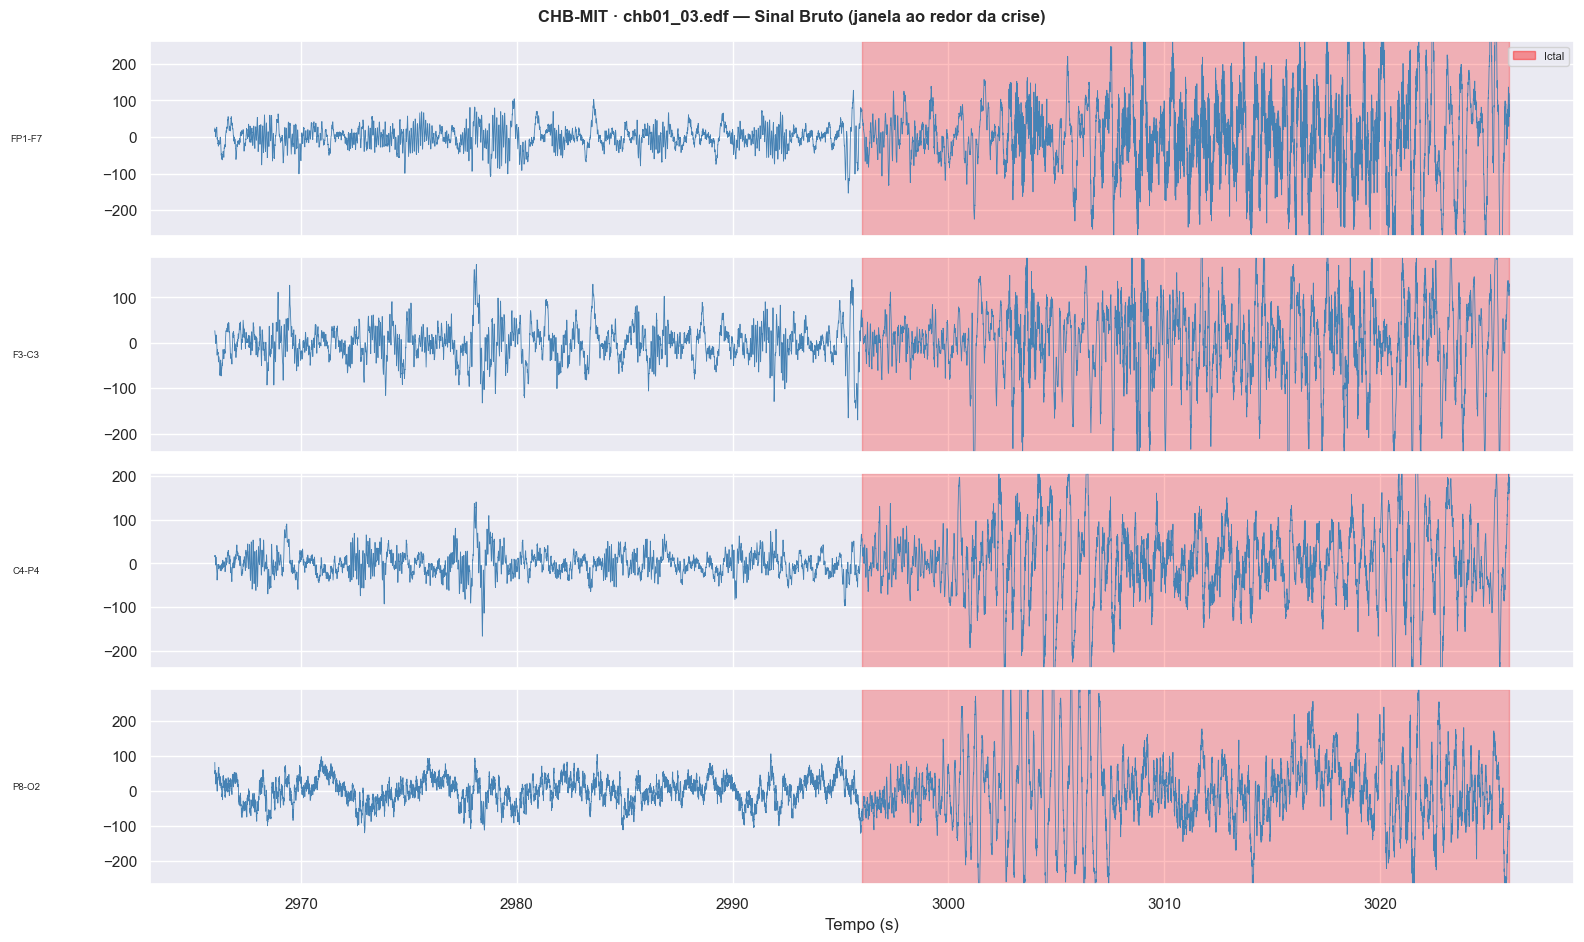

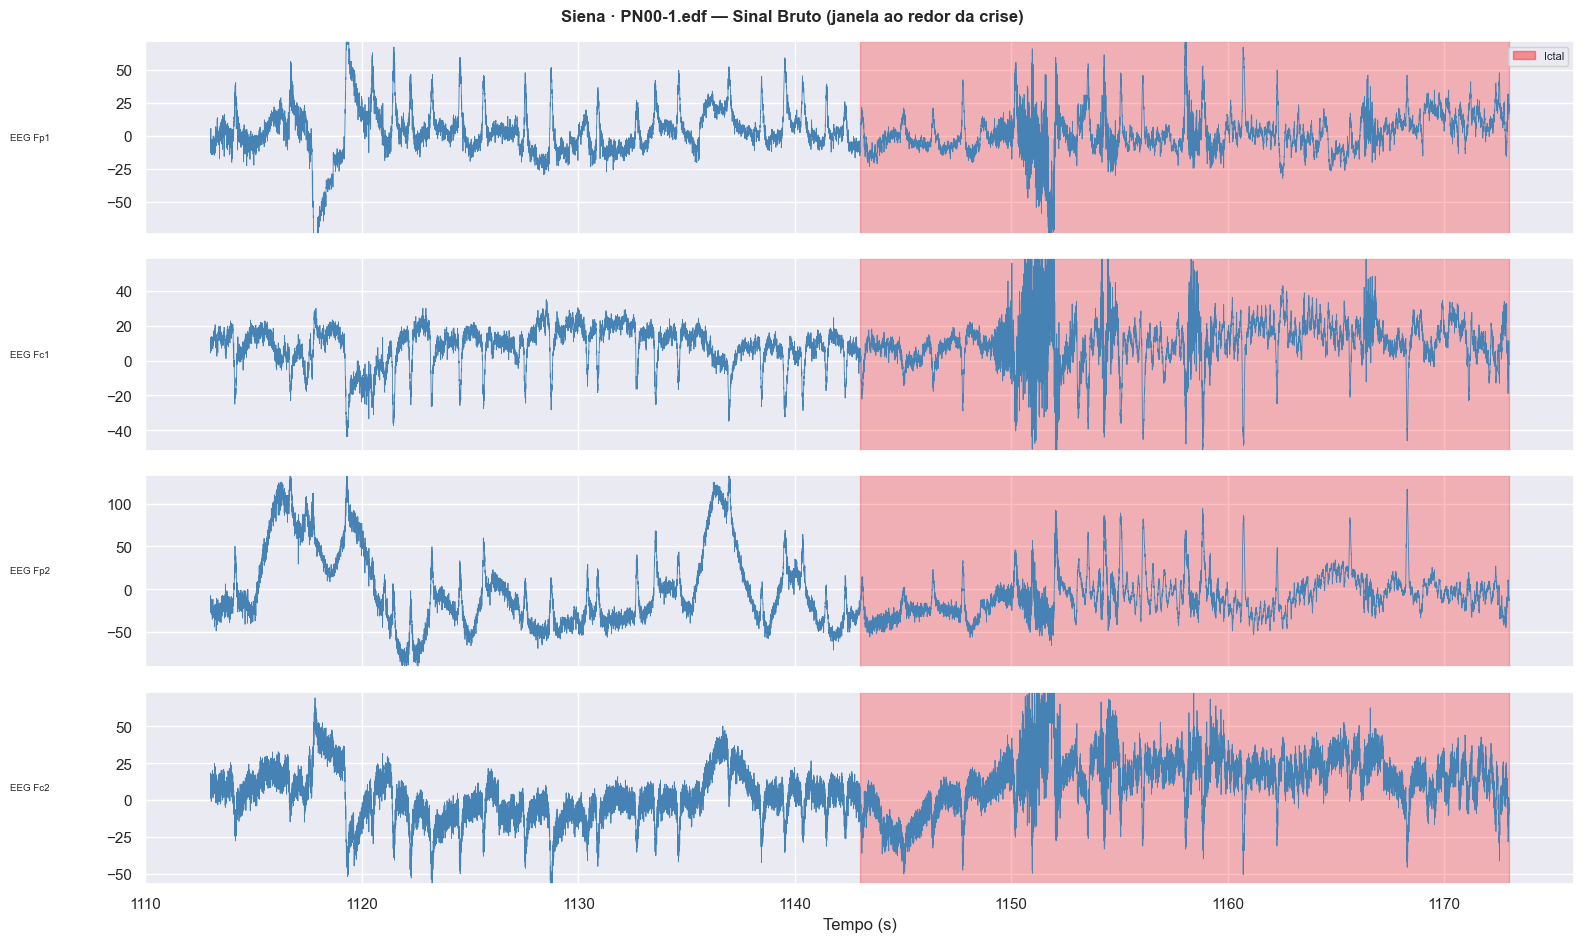

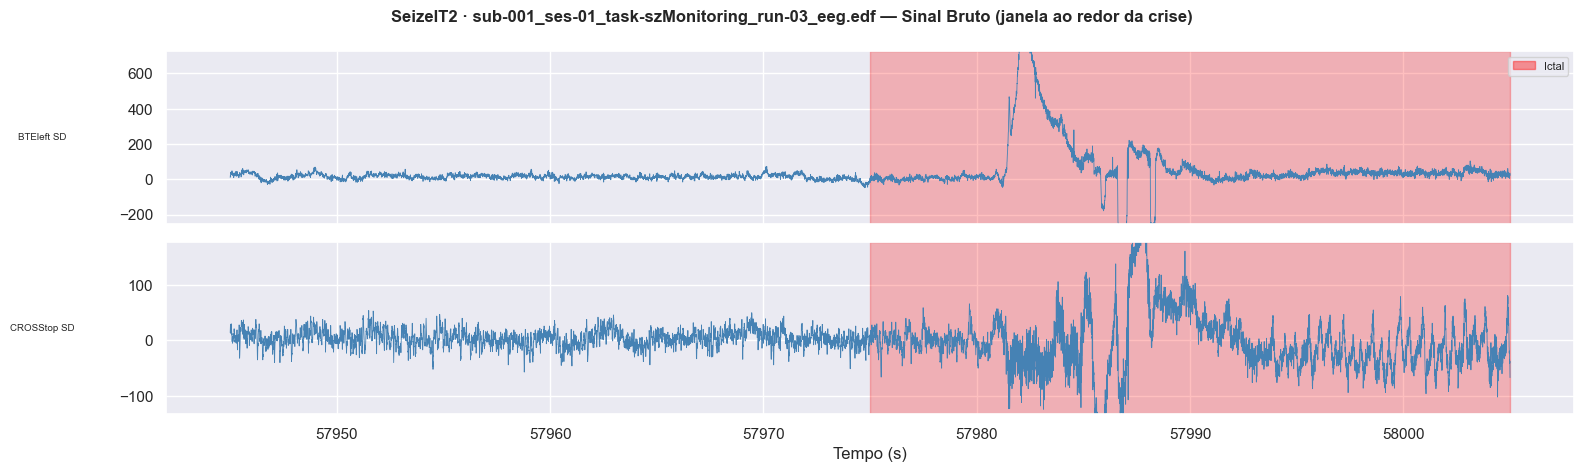

In [16]:
def plot_eeg_around_seizure(info, n_ch=4, t_win=60, title=''):
    data, sfreq, ch = info['data'], info['sfreq'], info['ch']
    seiz = info['seiz']
    s0   = max(0, seiz[0][0] - t_win // 2)
    i0   = int(s0 * sfreq)
    i1   = min(data.shape[1], i0 + int(t_win * sfreq))
    t    = np.linspace(s0, s0 + (i1-i0)/sfreq, i1-i0)

    step = max(1, len(ch) // n_ch)
    sel  = list(range(0, len(ch), step))[:n_ch]
    n_plot = len(sel)

    fig, axes = plt.subplots(n_plot, 1, figsize=(16, 2.4*n_plot), sharex=True)
    fig.suptitle(title or info['fname'], fontsize=12, fontweight='bold')
    if n_plot == 1: axes = [axes]

    for ax, ci in zip(axes, sel):
        seg = data[ci, i0:i1]
        ax.plot(t, seg, lw=0.6, color='steelblue')
        ax.set_ylabel(ch[ci], fontsize=7, rotation=0, labelpad=55, va='center')
        ylim = (np.percentile(seg,1)-20, np.percentile(seg,99)+20)
        ax.set_ylim(ylim)
        for s,e in seiz:
            ax.axvspan(max(s,s0), min(e,s0+t_win), alpha=0.25, color='red')
    axes[-1].set_xlabel('Tempo (s)')
    # Legenda manual
    from matplotlib.patches import Patch
    axes[0].legend(handles=[Patch(color='red',alpha=0.4,label='Ictal')],
                   loc='upper right', fontsize=8)
    plt.tight_layout(); plt.show()

for ds_name, info in datasets_eda.items():
    plot_eeg_around_seizure(info,
        title=f'{ds_name} · {info["fname"]} — Sinal Bruto (janela ao redor da crise)')

## 4.2 Comparação de PSD entre Datasets

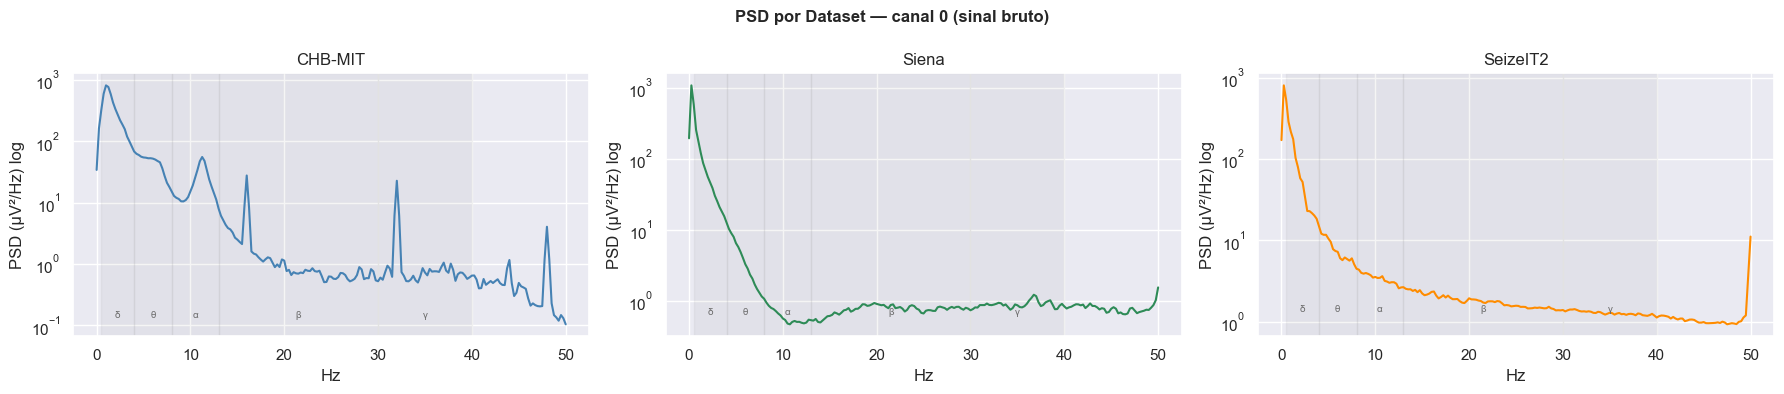

In [17]:
fig, axes = plt.subplots(1, len(datasets_eda), figsize=(6*len(datasets_eda), 4), sharey=False)
fig.suptitle('PSD por Dataset — canal 0 (sinal bruto)', fontsize=12, fontweight='bold')
if len(datasets_eda) == 1: axes = [axes]

colors = ['steelblue','seagreen','darkorange']
for ax, (ds_name, info), col in zip(axes, datasets_eda.items(), colors):
    sig  = info['data'][0]
    sf   = info['sfreq']
    f, p = welch(sig, fs=sf, nperseg=min(int(sf*4), len(sig)//2))
    mask = f <= 50
    ax.semilogy(f[mask], p[mask], color=col, lw=1.5)
    ax.set_title(ds_name); ax.set_xlabel('Hz')
    ax.set_ylabel('PSD (µV²/Hz) log')
    bands = {'δ':(0.5,4),'θ':(4,8),'α':(8,13),'β':(13,30),'γ':(30,40)}
    for bname,(bl,bh) in bands.items():
        ax.axvspan(bl,bh,alpha=0.08,color='gray')
        ax.text((bl+bh)/2, ax.get_ylim()[0]*2, bname, ha='center', fontsize=7, color='dimgray')

plt.tight_layout(); plt.show()

## 4.3 Tabela Comparativa dos Datasets

In [18]:
rows = []
for ds_name, info in datasets_eda.items():
    d, sf, ch = info['data'], info['sfreq'], info['ch']
    seiz = info['seiz']
    rows.append({
        'Dataset'     : ds_name,
        'Paciente'    : PILOT.get(ds_name, '—'),
        'Arquivo'     : os.path.basename(info['fname']),
        'fs (Hz)'     : int(sf),
        'Canais EEG'  : len(ch),
        'Duração (min)': round(info['dur']/60, 1),
        'Crises'      : len(seiz),
        'Dur. Crise(s)': ', '.join(f'{e-s}s' for s,e in seiz),
        'Notch (Hz)'  : int(info['notch']),
    })
pd.set_option('display.max_colwidth', 60)
df_comp = pd.DataFrame(rows)
display(df_comp)

,Dataset,Paciente,Arquivo,fs (Hz),Canais EEG,Duração (min),Crises,Dur. Crise(s),Notch (Hz)
0,CHB-MIT,—,chb01_03.edf,256,23,60.0,1,40s,60
1,Siena,PN00,PN00-1.edf,512,35,43.8,1,70s,50
2,SeizeIT2,sub-001,sub-001_ses-01_task-szMonitoring_run-03_eeg.edf,256,2,1083.0,1,72.0s,50


---
# Capítulo 5 — Pré-processamento

## 5.1 Funções de Filtragem

In [19]:
def notch_filter(data, sfreq, freq, Q=30):
    """Remove interferência de rede elétrica (IIR notch)."""
    b, a = iirnotch(freq, Q, sfreq)
    return filtfilt(b, a, data, axis=-1)

def highpass_filter(data, sfreq, cutoff=F_HP, order=F_ORDER):
    """Remove deriva DC e artefatos lentos (Butterworth passa-alta)."""
    sos = butter(order, cutoff, btype='high', fs=sfreq, output='sos')
    return sosfiltfilt(sos, data, axis=-1)

def lowpass_filter(data, sfreq, cutoff=F_LP, order=F_ORDER):
    """Remove EMG e ruído de alta frequência (Butterworth passa-baixa)."""
    sos = butter(order, cutoff, btype='low', fs=sfreq, output='sos')
    return sosfiltfilt(sos, data, axis=-1)

def preprocess(data, sfreq, notch_freq):
    """
    Pipeline: Notch → Passa-alta 0.5 Hz → Passa-baixa 40 Hz.
    data: (n_ch, n_samp) em µV.
    """
    out = notch_filter(data, sfreq, notch_freq)
    out = highpass_filter(out, sfreq)
    out = lowpass_filter(out, sfreq)
    return out

# ── Aplica em todos os arquivos EDA carregados ────────────────────────────────
for ds_name, info in datasets_eda.items():
    info['data_filt'] = preprocess(info['data'], info['sfreq'], info['notch'])
    rms_b = float(np.sqrt(np.mean(info['data'][0]**2)))
    rms_f = float(np.sqrt(np.mean(info['data_filt'][0]**2)))
    print(f"✅ {ds_name:10s} filtrado | RMS bruto={rms_b:.1f}µV → filtrado={rms_f:.1f}µV")

✅ CHB-MIT    filtrado | RMS bruto=40.7µV → filtrado=39.2µV
✅ Siena      filtrado | RMS bruto=34.4µV → filtrado=17.3µV
✅ SeizeIT2   filtrado | RMS bruto=37.2µV → filtrado=19.7µV


## 5.2 Visualização: Sinal e PSD — Bruto vs Filtrado

Comparação canal a canal e espectral antes e depois do pipeline de filtragem (Notch → passa-alta → passa-baixa), para cada dataset.

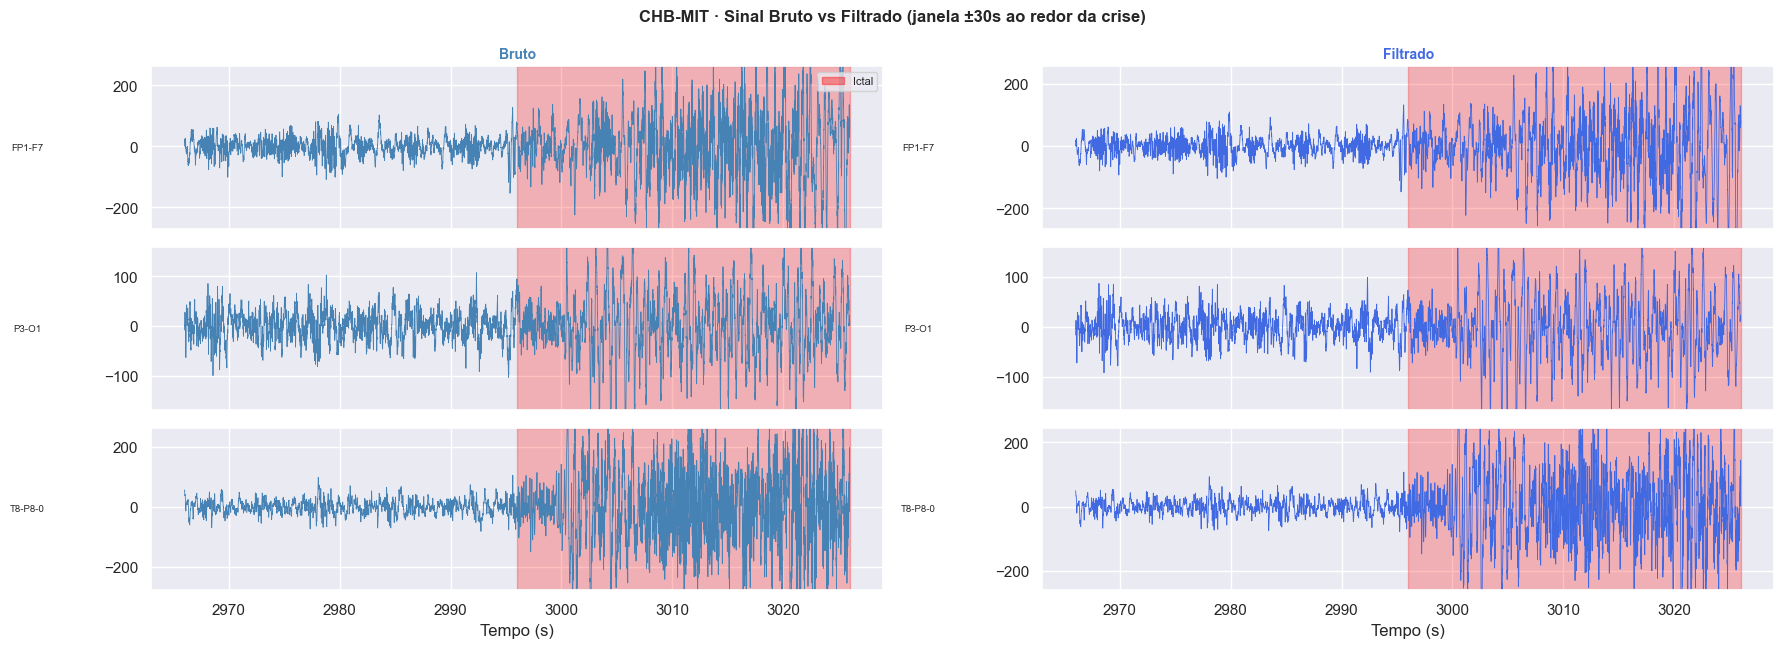

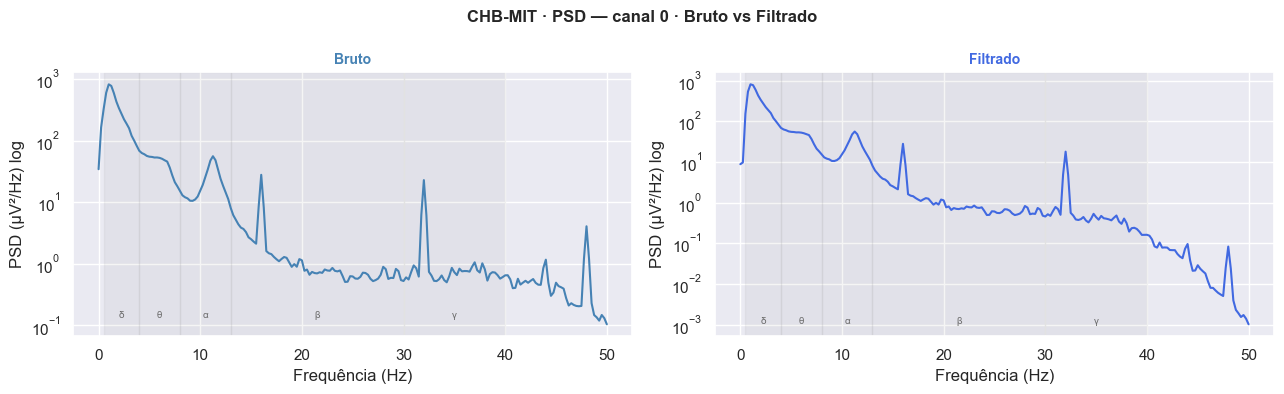

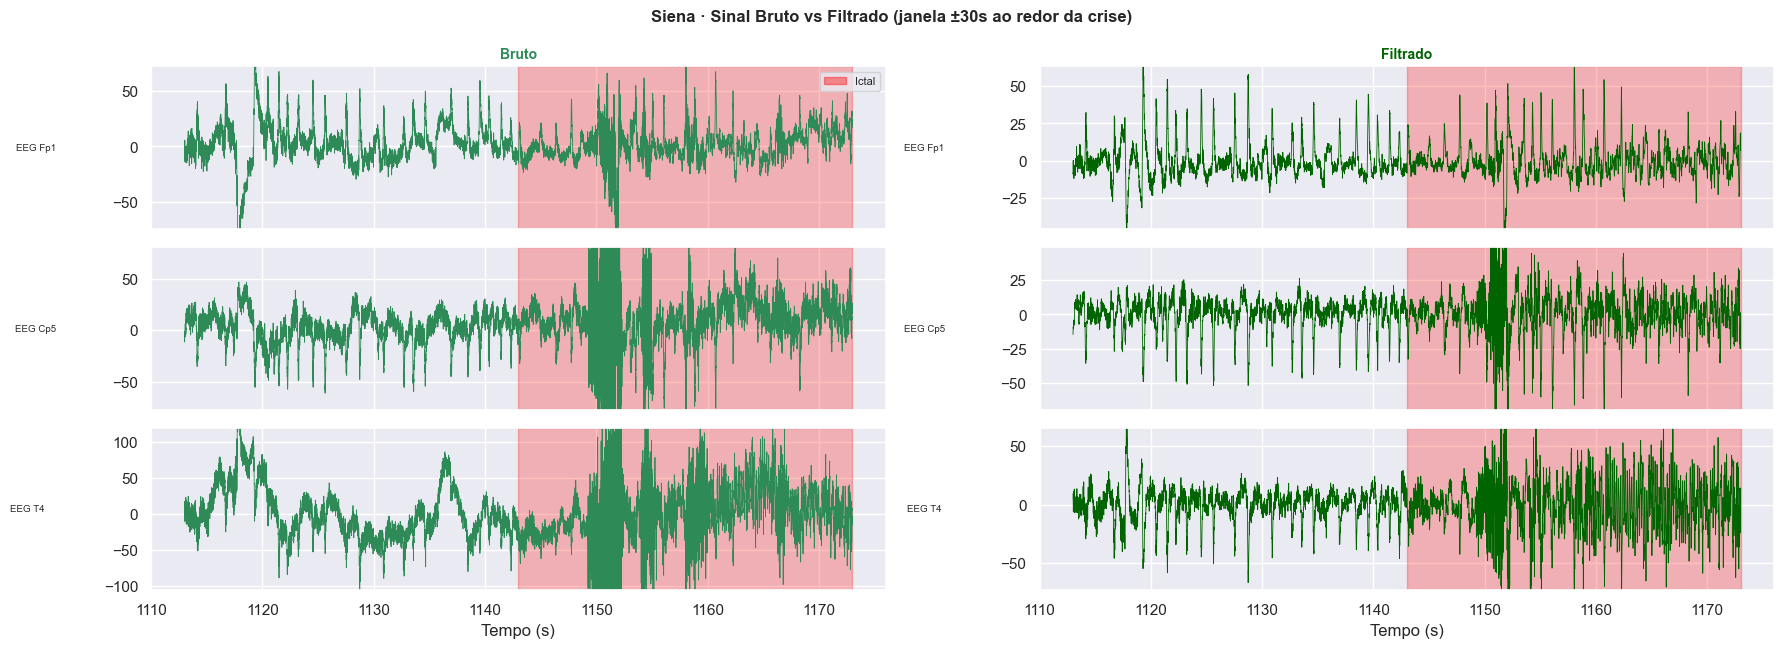

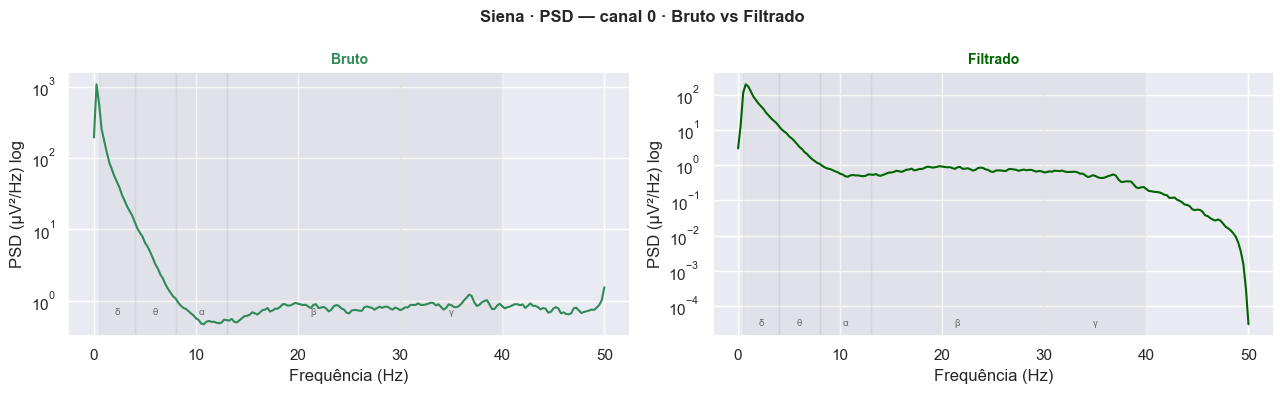

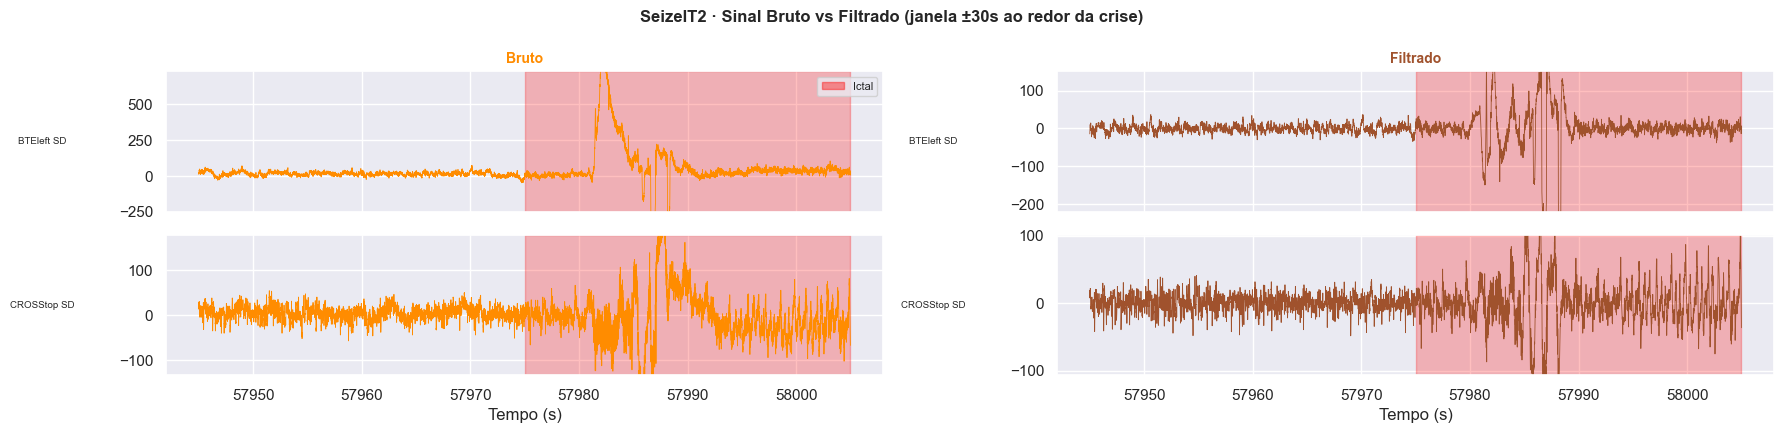

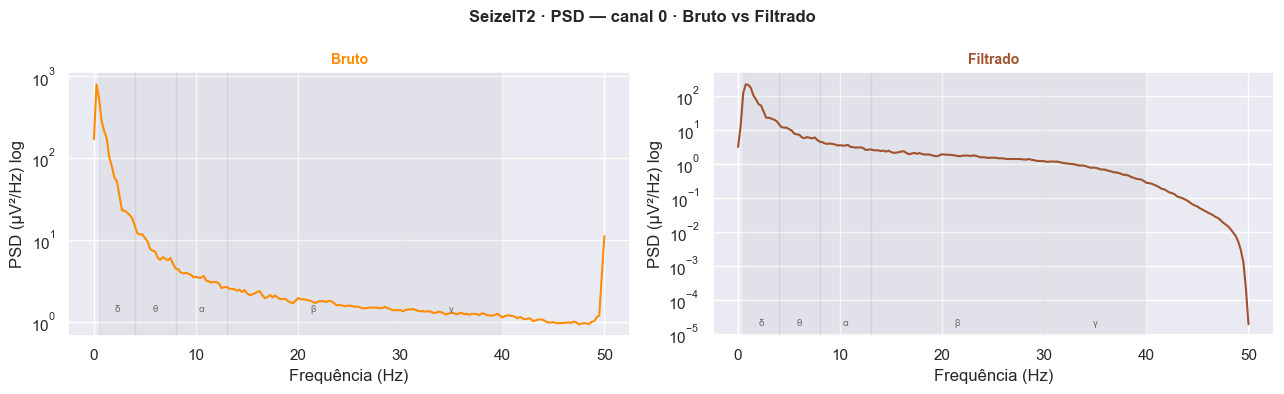

In [20]:
# ── Capítulo 5.2 — Sinal e PSD: Bruto vs Filtrado ────────────────────────────

t_win = 60  # segundos ao redor da crise para o plot de sinal
n_ch  = 3   # canais para mostrar

colors_raw  = ['steelblue',  'seagreen',   'darkorange']
colors_filt = ['royalblue',  'darkgreen',  'sienna']

for (ds_name, info), c_raw, c_filt in zip(datasets_eda.items(), colors_raw, colors_filt):
    data_b = info['data']
    data_f = info['data_filt']
    sf     = info['sfreq']
    ch     = info['ch']
    seiz   = info['seiz']

    s0  = max(0, seiz[0][0] - t_win // 2)
    i0  = int(s0 * sf)
    i1  = min(data_b.shape[1], i0 + int(t_win * sf))
    t   = np.linspace(s0, s0 + (i1 - i0) / sf, i1 - i0)

    step   = max(1, len(ch) // n_ch)
    sel    = list(range(0, len(ch), step))[:n_ch]
    n_plot = len(sel)

    # ── Plot 1: Sinal bruto vs filtrado ──────────────────────────────────────
    fig, axes = plt.subplots(n_plot, 2, figsize=(18, 2.2 * n_plot), sharex='col')
    fig.suptitle(f'{ds_name} · Sinal Bruto vs Filtrado (janela ±{t_win//2}s ao redor da crise)',
                 fontsize=12, fontweight='bold')
    if n_plot == 1:
        axes = axes.reshape(1, 2)

    for row, ci in enumerate(sel):
        seg_b = data_b[ci, i0:i1]
        seg_f = data_f[ci, i0:i1]
        for col_idx, (seg, color, label) in enumerate([
            (seg_b, c_raw,  'Bruto'),
            (seg_f, c_filt, 'Filtrado'),
        ]):
            ax = axes[row, col_idx]
            ax.plot(t, seg, lw=0.6, color=color)
            ax.set_ylabel(ch[ci], fontsize=7, rotation=0, labelpad=55, va='center')
            ylim = (np.percentile(seg, 1) - 20, np.percentile(seg, 99) + 20)
            ax.set_ylim(ylim)
            for s, e in seiz:
                ax.axvspan(max(s, s0), min(e, s0 + t_win), alpha=0.25, color='red')
            if row == 0:
                ax.set_title(label, fontsize=10, fontweight='bold', color=color)

    axes[-1, 0].set_xlabel('Tempo (s)')
    axes[-1, 1].set_xlabel('Tempo (s)')
    from matplotlib.patches import Patch
    axes[0, 0].legend(handles=[Patch(color='red', alpha=0.4, label='Ictal')],
                      loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

    # ── Plot 2: PSD bruto vs filtrado ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
    fig.suptitle(f'{ds_name} · PSD — canal 0 · Bruto vs Filtrado',
                 fontsize=12, fontweight='bold')

    bands = {'δ': (0.5, 4), 'θ': (4, 8), 'α': (8, 13), 'β': (13, 30), 'γ': (30, 40)}
    nperseg = min(int(sf * 4), data_b.shape[1] // 2)

    for ax, (data, color, label) in zip(axes, [
        (data_b, c_raw,  'Bruto'),
        (data_f, c_filt, 'Filtrado'),
    ]):
        f, p = welch(data[0], fs=sf, nperseg=nperseg)
        mask = f <= 50
        ax.semilogy(f[mask], p[mask], color=color, lw=1.5)
        ax.set_title(label, fontsize=10, fontweight='bold', color=color)
        ax.set_xlabel('Frequência (Hz)')
        ax.set_ylabel('PSD (µV²/Hz) log')
        for bname, (bl, bh) in bands.items():
            ax.axvspan(bl, bh, alpha=0.08, color='gray')
            ax.text((bl + bh) / 2, ax.get_ylim()[0] * 2, bname,
                    ha='center', fontsize=7, color='dimgray')

    plt.tight_layout()
    plt.show()

---
# Capítulo 6 — Rotulagem Temporal

```
╔════════════════════════════════════════════════════════════════════════════════════════╗
║  Linha do tempo de um EDF com uma crise                                                ║
║                                                                                        ║
║  ├── INTERICTAL ──┤  PRÉ-ICTAL (≤10 min) ├── ICTAL ─┤ PÓS-ICTAL (≤10min) ─┤            ║
║                   ↑                        ↑          ↑                     ↑          ║
║          seiz_start - PRE_SEC         seiz_start  seiz_end        seiz_end + POST_SEC  ║
╚════════════════════════════════════════════════════════════════════════════════════════╝
```

**Casos especiais:**
- Se a crise ocorre nos **primeiros < PRE_SEC** da gravação → pré-ictal = tudo disponível antes da crise (sem padding artificial).
- **Interictal** = amostras com distância ≥ IGAP_SEC de qualquer pré-ictal/ictal/pós-ictal.
- Amostras na zona de transição entre pós-ictal de uma crise e pré-ictal da próxima são marcadas como `unknown (-1)` e descartadas no janelamento.

**Classes:** `0=interictal  1=pré-ictal  2=ictal  3=pós-ictal  -1=unknown`

In [21]:
def build_label_array(n_samples, sfreq, seizure_intervals,
                      pre_sec=PRE_SEC, post_sec=POST_SEC, igap_sec=IGAP_SEC):
    """
    Constrói vetor de labels amostra-a-amostra.

    Estratégia vetorizada (eficiente para gravações longas):
      1. Inicia tudo como UNKNOWN.
      2. Marca ICTAL, PREICTAL, POSTICTAL em passagem direta.
      3. Uma amostra é INTERICTAL se:
         - ainda é UNKNOWN, E
         - está a pelo menos igap_sec de qualquer borda dos eventos marcados.
    """
    from scipy.ndimage import uniform_filter1d

    labels = np.full(n_samples, LBL['unknown'], dtype=np.int8)

    # ── Passagem 1: marca ictal / pré-ictal / pós-ictal ──────────────────────
    for (s_s, e_s) in seizure_intervals:
        i_s = int(s_s * sfreq)
        i_e = min(int(e_s * sfreq), n_samples)

        # Ictal
        labels[i_s:i_e] = LBL['ictal']

        # Pré-ictal (pode ser menor que pre_sec se crise no início)
        pre_start = max(0, i_s - int(pre_sec * sfreq))
        pre_slice = labels[pre_start:i_s]
        pre_slice[pre_slice != LBL['ictal']] = LBL['preictal']

        # Pós-ictal (idem)
        post_end = min(n_samples, i_e + int(post_sec * sfreq))
        post_slice = labels[i_e:post_end]
        post_slice[post_slice != LBL['ictal']] = LBL['postictal']

    # ── Passagem 2: marca interictal com margem de segurança ─────────────────
    # uniform_filter1d opera em streaming (O(n)), sem alocar estrutura gigante
    # como o binary_dilation fazia com gap_samp*2+1 elementos.
    event_mask = (labels != LBL['unknown']).astype(np.float32)
    gap_samp = int(igap_sec * sfreq)
    if gap_samp > 0 and event_mask.any():
        smoothed   = uniform_filter1d(event_mask, size=gap_samp * 2 + 1, mode='constant')
        near_event = smoothed > 0
    else:
        near_event = event_mask.astype(bool)

    # Interictal = unknown E não perto de evento
    interictal_mask = (~near_event) & (labels == LBL['unknown'])
    labels[interictal_mask] = LBL['interictal']

    return labels

# ── Testa com o primeiro arquivo CHB-MIT ─────────────────────────────────────
info_chb = datasets_eda.get('CHB-MIT')
if info_chb:
    lbl_chb = build_label_array(
        info_chb['data_filt'].shape[1], info_chb['sfreq'], info_chb['seiz'])

    u, c = np.unique(lbl_chb[lbl_chb >= 0], return_counts=True)
    print(f"📊 Rotulagem CHB-MIT · {info_chb['fname']} (fs={info_chb['sfreq']}Hz)")
    for lv, cnt in zip(u, c):
        dur = cnt / info_chb['sfreq']
        pct = cnt / len(lbl_chb[lbl_chb >= 0]) * 100
        print(f"   {LBL_NAMES[lv]:12s}: {cnt:8d} amostras = {dur:6.0f}s = {dur/60:.1f}min ({pct:.1f}%)")
    unk = (lbl_chb == -1).sum()
    print(f"   {'unknown':12s}: {unk:8d} amostras (descartadas no janelamento)")

📊 Rotulagem CHB-MIT · chb01_03.edf (fs=256.0Hz)
   interictal  :   459776 amostras =   1796s = 29.9min (59.9%)
   preictal    :   153600 amostras =    600s = 10.0min (20.0%)
   ictal       :    10240 amostras =     40s = 0.7min (1.3%)
   postictal   :   144384 amostras =    564s = 9.4min (18.8%)
   unknown     :   153600 amostras (descartadas no janelamento)


## 6.1 Visualização da Rotulagem no Tempo

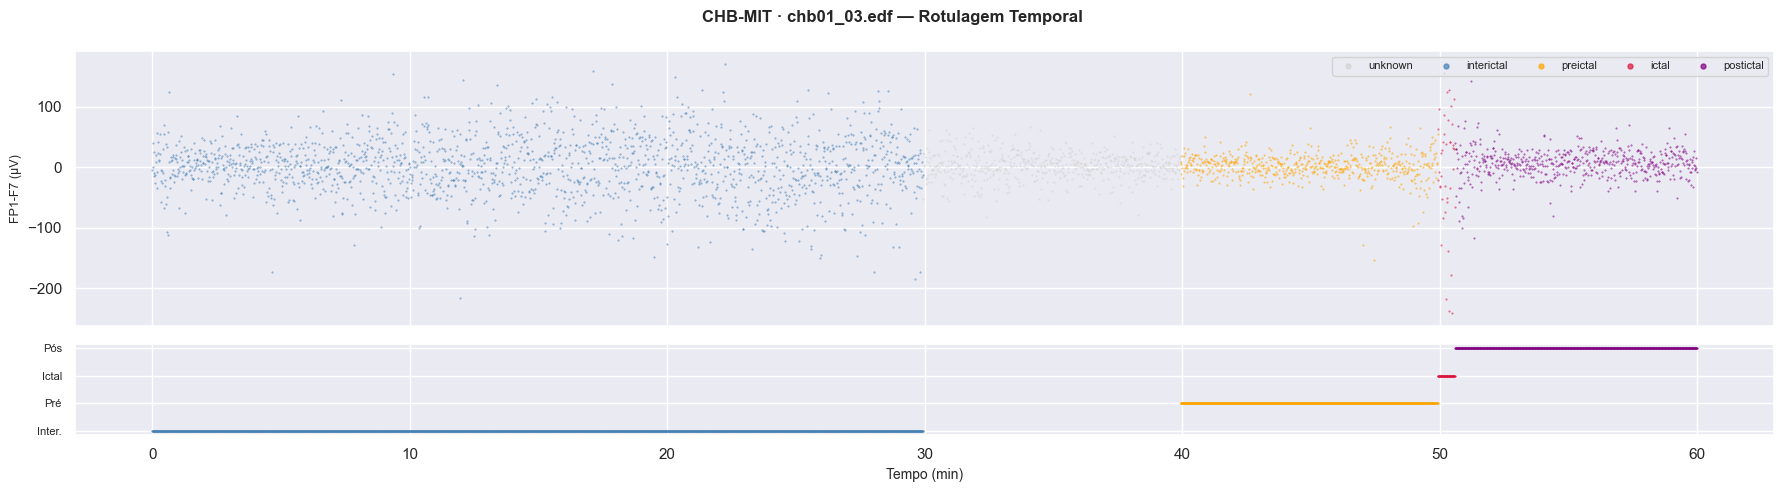

In [22]:
def plot_label_timeline(data_filt, labels, sfreq, ch_names, title=''):
    n   = labels.shape[0]
    dur = n / sfreq / 60   # minutos
    ds  = max(1, int(sfreq * 1))   # 1 amostra/segundo para o plot

    t  = np.arange(0, n, ds) / sfreq / 60
    s  = data_filt[0, ::ds]
    lb = labels[::ds]

    color_map = {LBL['interictal']:'steelblue', LBL['preictal']:'orange',
                 LBL['ictal']:'crimson', LBL['postictal']:'purple',
                 LBL['unknown']:'lightgray'}

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 5), sharex=True,
                                    gridspec_kw={'height_ratios':[3,1]})
    fig.suptitle(title, fontsize=12, fontweight='bold')

    for lv in sorted(set(lb)):
        m = lb == lv
        ax1.scatter(t[m], s[m], s=0.2, c=color_map[lv],
                    label=LBL_NAMES.get(lv,'?'), alpha=0.7)
    ax1.set_ylabel(f'{ch_names[0]} (µV)', fontsize=9)
    ax1.legend(loc='upper right', markerscale=8, fontsize=8, ncol=5)

    for lv in [0,1,2,3]:
        m = labels[::ds] == lv
        ax2.scatter(t[m], np.full(m.sum(), lv), s=0.3, c=color_map[lv])
    ax2.set_yticks([0,1,2,3])
    ax2.set_yticklabels(['Inter.','Pré','Ictal','Pós'], fontsize=8)
    ax2.set_xlabel('Tempo (min)', fontsize=10)

    plt.tight_layout(); plt.show()

if info_chb:
    plot_label_timeline(info_chb['data_filt'], lbl_chb,
                        info_chb['sfreq'], info_chb['ch'],
                        title=f"CHB-MIT · {info_chb['fname']} — Rotulagem Temporal")

---
# Capítulo 7 — Janelamento com 50% de Overlap

**Regras de atribuição de label por janela:**
1. Janelas com qualquer amostra `unknown` → **descartadas**.
2. Janelas com ≥ 1 amostra `ictal` → label `ictal` (ictal tem prioridade).
3. Demais janelas: label da classe majoritária, desde que represente ≥ 80% das amostras (janelas mistas → descartadas).

In [23]:
def extract_windows(data, labels, sfreq,
                    win_sec=WIN_SEC, overlap=OVERLAP,
                    min_pure=0.80):
    """
    Retorna (windows, win_labels, win_times_s):
        windows      : (N, n_ch, win_samples)  float32
        win_labels   : (N,)                    int8
        win_times_s  : (N,)                    float — segundo de início
    """
    ws   = int(win_sec * sfreq)
    step = max(1, int(ws * (1 - overlap)))

    wins, lbls, times = [], [], []
    for start in range(0, data.shape[1] - ws + 1, step):
        end    = start + ws
        seg_l  = labels[start:end]

        if (seg_l == LBL['unknown']).any():
            continue

        # Prioridade ictal
        if (seg_l == LBL['ictal']).any():
            lv = LBL['ictal']
        else:
            uv, uc = np.unique(seg_l, return_counts=True)
            mi = np.argmax(uc)
            if uc[mi] / ws < min_pure:
                continue
            lv = int(uv[mi])

        wins.append(data[:, start:end].astype(np.float32))
        lbls.append(lv)
        times.append(start / sfreq)

    if not wins:
        return (np.empty((0, data.shape[0], ws), np.float32),
                np.empty(0, np.int8), np.empty(0))
    return (np.stack(wins),
            np.array(lbls, np.int8),
            np.array(times))

# ── Teste ─────────────────────────────────────────────────────────────────────
if info_chb:
    W, L, T = extract_windows(info_chb['data_filt'], lbl_chb, info_chb['sfreq'])
    print(f"✅ Janelas extraídas: {len(W)} | shape: {W.shape}")
    u, c = np.unique(L, return_counts=True)
    for lv, cnt in zip(u, c):
        print(f"   {LBL_NAMES[lv]:12s}: {cnt:5d} janelas ({cnt/len(L)*100:.1f}%)")

    # Alerta desbalanceamento
    if len(c) > 1:
        ratio = c.max() / (c.min() + 1e-9)
        status = "⚠️  Severo" if ratio > 20 else "ℹ️  Moderado" if ratio > 5 else "✅ OK"
        print(f"\n   Ratio max/min: {ratio:.0f}x  → {status}")

✅ Janelas extraídas: 1498 | shape: (1498, 23, 1024)
   interictal  :   897 janelas (59.9%)
   preictal    :   299 janelas (20.0%)
   ictal       :    21 janelas (1.4%)
   postictal   :   281 janelas (18.8%)

   Ratio max/min: 43x  → ⚠️  Severo


---
# Capítulo 8 — Salvamento Nível 1 (Sinal Filtrado + Labels/Amostra)

O Nível 1 armazena o **sinal filtrado completo** (antes do janelamento) junto com o vetor de labels amostra-a-amostra.  
Isso permite re-janelamento futuro com outros parâmetros sem reprocessar os EDFs originais.

In [24]:
def save_level1(data_filt, labels, sfreq, ch_names,
                dataset, patient, fname, out_dir=L1_DIR):
    """Salva sinal filtrado + labels/amostra em .npz + metadados JSON."""
    key  = f'{dataset}__{patient}__{os.path.splitext(os.path.basename(fname))[0]}'
    npz  = os.path.join(out_dir, key + '_L1.npz')
    meta = os.path.join(out_dir, key + '_L1_meta.json')

    if not os.path.exists(npz):
        np.savez_compressed(npz,
                            data=data_filt.astype(np.float32),
                            labels=labels,
                            sfreq=np.float32(sfreq),
                            ch_names=np.array(ch_names))
        m = {'dataset':dataset,'patient':patient,'source':str(fname),
             'sfreq':sfreq,'n_ch':len(ch_names),'n_samp':int(data_filt.shape[1]),
             'duration_s':round(data_filt.shape[1]/sfreq,2),
             'ch_names':ch_names,
             'label_dist':{LBL_NAMES[int(v)]:int(c)
                           for v,c in zip(*np.unique(labels[labels>=0],
                                                     return_counts=True))},
             'filter':{'hp_hz':F_HP,'lp_hz':F_LP,'notch_hz':
                       NOTCH.get(dataset,50),'order':F_ORDER}}
        with open(meta,'w') as f: json.dump(m, f, indent=2)
        print(f"💾 L1: {os.path.basename(npz)}")
    else:
        print(f"⏭️  Já existe: {os.path.basename(npz)}")
    return npz

# ── Pipeline completo: todos os datasets / pacientes piloto ──────────────────
l1_index = {}   # { 'CHBMIT__chb01__chb01_03': '/path/..._L1.npz', ... }

def run_l1_pipeline(dataset_name, patient, ann_dict,
                    edf_root, notch_freq):
    """
    Para cada arquivo com crise do paciente:
      1. Carrega EDF
      2. Filtra
      3. Rotula amostra-a-amostra
      4. Salva Nível 1
    """
    count = 0
    for fname, seiz in ann_dict.items():
        edf_path = os.path.join(edf_root, fname)
        if not os.path.exists(edf_path):
            print(f"  ⚠️  {fname} não encontrado, pulando.")
            continue
        data, sfreq, ch, dur = load_edf(edf_path)
        data_f = preprocess(data, sfreq, notch_freq)
        labels = build_label_array(data_f.shape[1], sfreq, seiz)
        npz    = save_level1(data_f, labels, sfreq, ch,
                             dataset_name, patient, fname)
        key    = f'{dataset_name}__{patient}__{os.path.splitext(os.path.basename(fname))[0]}'
        l1_index[key] = npz
        count += 1
    print(f"✅ {dataset_name} {patient}: {count} arquivos L1 salvos.")

# ── Pipeline L1: percorre TODOS os pacientes de TODOS os datasets ─────────────
_DS = [
    ('CHBMIT',  chbmit_ann_all,  lambda pat: os.path.join(CHBMIT_DIR, pat)),
    ('Siena',   siena_ann_all,   lambda pat: os.path.join(SIENA_DIR, pat)),
    ('SeizeIT2',seizeit_ann_all, lambda pat: os.path.join(SEIZEIT_DIR, pat, SEIZEIT_SESSION, 'eeg')),
]

for ds_name, ann_all, edf_root_fn in _DS:
    for pat, ann_dict in ann_all.items():
        if not ann_dict:
            continue
        run_l1_pipeline(ds_name, pat, ann_dict, edf_root_fn(pat), NOTCH[ds_name])

print(f"\n📦 Total entradas L1: {len(l1_index)}")

⏭️  Já existe: CHBMIT__chb01__chb01_03_L1.npz
⏭️  Já existe: CHBMIT__chb01__chb01_04_L1.npz
⏭️  Já existe: CHBMIT__chb01__chb01_15_L1.npz
⏭️  Já existe: CHBMIT__chb01__chb01_16_L1.npz
⏭️  Já existe: CHBMIT__chb01__chb01_18_L1.npz
⏭️  Já existe: CHBMIT__chb01__chb01_21_L1.npz
⏭️  Já existe: CHBMIT__chb01__chb01_26_L1.npz
✅ CHBMIT chb01: 7 arquivos L1 salvos.
⏭️  Já existe: Siena__PN00__PN00-1_L1.npz
⏭️  Já existe: Siena__PN00__PN00-2_L1.npz
⏭️  Já existe: Siena__PN00__PN00-3_L1.npz
⏭️  Já existe: Siena__PN00__PN00-4_L1.npz
⏭️  Já existe: Siena__PN00__PN00-5_L1.npz
✅ Siena PN00: 5 arquivos L1 salvos.
⏭️  Já existe: SeizeIT2__sub-001__sub-001_ses-01_task-szMonitoring_run-03_eeg_L1.npz
⏭️  Já existe: SeizeIT2__sub-001__sub-001_ses-01_task-szMonitoring_run-05_eeg_L1.npz
⏭️  Já existe: SeizeIT2__sub-001__sub-001_ses-01_task-szMonitoring_run-07_eeg_L1.npz
⏭️  Já existe: SeizeIT2__sub-001__sub-001_ses-01_task-szMonitoring_run-08_eeg_L1.npz
✅ SeizeIT2 sub-001: 4 arquivos L1 salvos.

📦 Total ent

---
# Capítulo 9 — Salvamento Nível 2 (Janelas + Labels/Janela)

Lê os NPZs do Nível 1 e extrai janelas. Salva um NPZ por paciente/dataset com **todas as janelas** — o undersampling será aplicado **apenas no treino** nos modelos.

In [25]:
def save_level2(windows, win_labels, win_times, sfreq,
                dataset, patient, out_dir=L2_DIR):
    """Salva janelas rotuladas em .npz por paciente."""
    key  = f'{dataset}__{patient}'
    npz  = os.path.join(out_dir, key + '_L2.npz')
    meta = os.path.join(out_dir, key + '_L2_meta.json')

    np.savez_compressed(npz,
                        windows=windows,
                        labels=win_labels,
                        times=win_times)
    u, c = np.unique(win_labels, return_counts=True)
    m = {'dataset':dataset,'patient':patient,'sfreq':float(sfreq),
         'n_windows':int(len(windows)),'n_ch':int(windows.shape[1]),
         'win_samples':int(windows.shape[2]),
         'win_sec':WIN_SEC,'overlap':OVERLAP,
         'label_dist':{LBL_NAMES[int(v)]:int(ct) for v,ct in zip(u,c)}}
    with open(meta,'w') as f: json.dump(m, f, indent=2)
    print(f"💾 L2: {os.path.basename(npz)}  ({len(windows)} janelas)")
    return npz

# ── Agrupa entradas L1 por (dataset, patient) ─────────────────────────────────
from collections import defaultdict
l2_index = {}   # { 'CHBMIT__chb01': '/path/..._L2.npz' }

grouped = defaultdict(list)
for key, npz_path in l1_index.items():
    ds, pat, _ = key.split('__', 2)
    grouped[(ds, pat)].append(npz_path)

for (ds, pat), npz_list in grouped.items():
    all_wins, all_lbls, all_times = [], [], []
    sfreq_used = None
    for npz_path in npz_list:
        npz   = np.load(npz_path, allow_pickle=True)
        data  = npz['data']
        lbls  = npz['labels']
        sf    = float(npz['sfreq'])
        sfreq_used = sf
        W, L, T = extract_windows(data, lbls, sf)
        if len(W) > 0:
            all_wins.append(W)
            all_lbls.append(L)
            all_times.append(T)

    if all_wins:
        W_cat = np.concatenate(all_wins)
        L_cat = np.concatenate(all_lbls)
        T_cat = np.concatenate(all_times)
        npz2  = save_level2(W_cat, L_cat, T_cat, sfreq_used, ds, pat)
        l2_index[f'{ds}__{pat}'] = npz2

print(f"\n📦 Total entradas L2: {len(l2_index)}")

💾 L2: CHBMIT__chb01_L2.npz  (8736 janelas)
💾 L2: Siena__PN00_L2.npz  (3810 janelas)
💾 L2: SeizeIT2__sub-001_L2.npz  (101825 janelas)

📦 Total entradas L2: 3


## 9.1 Distribuição Final de Classes por Paciente

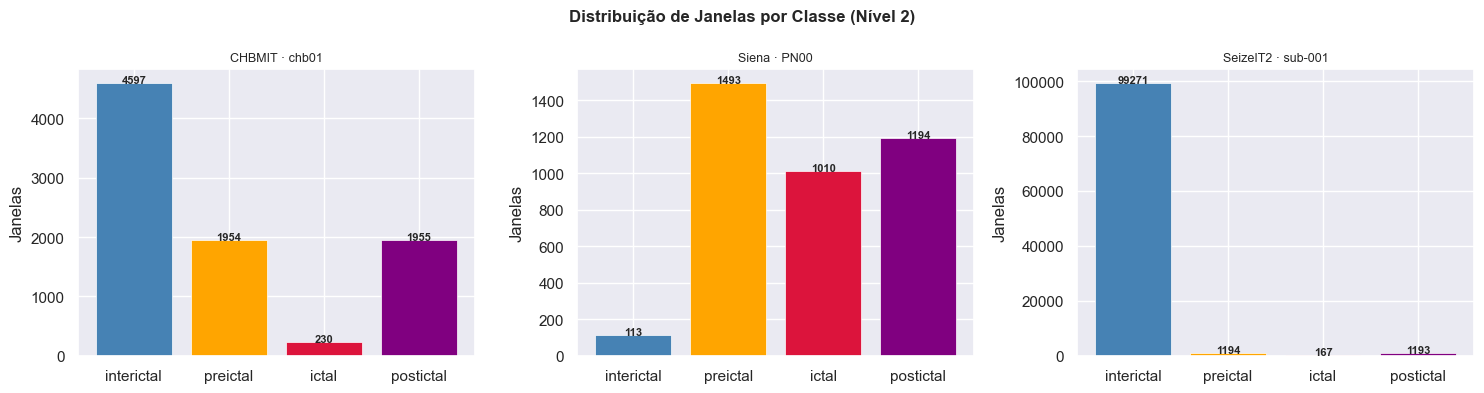

In [26]:
fig, axes = plt.subplots(1, max(1,len(l2_index)), figsize=(5*max(1,len(l2_index)), 4))
if len(l2_index) == 1: axes = [axes]
fig.suptitle('Distribuição de Janelas por Classe (Nível 2)', fontsize=12, fontweight='bold')

pal = {LBL['interictal']:'steelblue', LBL['preictal']:'orange',
       LBL['ictal']:'crimson',        LBL['postictal']:'purple'}

for ax, (key, npz_path) in zip(axes, l2_index.items()):
    npz = np.load(npz_path)
    L   = npz['labels']
    u, c = np.unique(L, return_counts=True)
    colors_bar = [pal.get(int(v),'gray') for v in u]
    bars = ax.bar([LBL_NAMES[int(v)] for v in u], c, color=colors_bar,
                  edgecolor='white', linewidth=0.5)
    ax.set_title(key.replace('__',' · '), fontsize=9)
    ax.set_ylabel('Janelas')
    for b, cnt in zip(bars, c):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                str(cnt), ha='center', fontsize=8, fontweight='bold')

plt.tight_layout(); plt.show()

---
# Capítulo 10 — Extração de Features

Extraímos três grupos de features por canal em cada janela:

| Grupo | Features | Qtde/canal |
|-------|---------|-----------|
| **Temporal** | Mean, Std, Variance, RMS, Skewness, Kurtosis, Zero-crossing rate, Line length, Hjorth (Activity, Mobility, Complexity) | 10 |
| **Espectral** | Potência de 5 bandas (δ/θ/α/β/γ), Entropia espectral, Frequência dominante, Razões de bandas (θ/α, β/α, γ/β) | 10 |
| **Não-linear** | Sample Entropy, Hurst Exponent, DWT energia (db4, 4 níveis: D1–D4) | 6 |

**Total:** 26 features × n_canais por janela.

In [27]:
# ── Features temporais ────────────────────────────────────────────────────────
def temporal_feats(sig):
    """6 features temporais."""
    d1  = np.diff(sig)
    act = float(np.var(sig))
    mob = float(np.sqrt(np.var(d1) / (np.var(sig) + 1e-10)))
    return np.array([
        float(np.std(sig)),
        float(np.var(sig)),
        float(np.sqrt(np.mean(sig**2))),            # RMS
        float(np.sum(np.abs(np.diff(sig)))),        # Line length
        act,                                        # Hjorth Activity
        mob,                                        # Hjorth Mobility
    ], dtype=np.float32)

# ── Features espectrais ───────────────────────────────────────────────────────
_BANDS = {'delta':(0.5,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,40)}

def spectral_feats(sig, sfreq):
    """6 features espectrais (PSD via Welch)."""
    nperseg = min(int(sfreq*4), max(int(sfreq), len(sig)//2))
    f, psd  = welch(sig, fs=sfreq, nperseg=nperseg)
    bp = {}
    for bname,(lo,hi) in _BANDS.items():
        idx = (f >= lo) & (f <= hi)
        bp[bname] = float(np.trapz(psd[idx], f[idx])) if idx.sum()>1 else 0.0
    psd_norm = psd / (psd.sum() + 1e-10)
    psd_norm = psd_norm[psd_norm > 0]
    sp_ent   = float(-np.sum(psd_norm * np.log(psd_norm)))
    return np.array([
        bp['delta'], bp['theta'], bp['alpha'], bp['beta'], bp['gamma'],
        sp_ent,
    ], dtype=np.float32)

# ── Features não-lineares (DWT) ───────────────────────────────────────────────
def dwt_energy_feats(sig, wavelet='db4', level=4):
    """4 features: energia das sub-bandas de detalhe DWT."""
    coeffs = pywt.wavedec(sig.astype(np.float64), wavelet, level=level)
    return np.array([float(np.sum(c**2)) for c in coeffs[1:level+1]],
                    dtype=np.float32)

print("✅ Funções de features definidas")
print(f"   Temporal  :  6 features/canal")
print(f"   Espectral :  6 features/canal")
print(f"   DWT       :  4 features/canal")
print(f"   Total     : 16 features/canal")

✅ Funções de features definidas
   Temporal  :  6 features/canal
   Espectral :  6 features/canal
   DWT       :  4 features/canal
   Total     : 16 features/canal


In [40]:
def extract_features_batch(windows, sfreq, desc=''):
    """
    Extrai features e agrega por canal (média + std).
    windows: (N, n_ch, win_samples) → retorna (N, 32)
    Independente do número de canais — permite LOSO cross-dataset.
    """
    N, n_ch, ws = windows.shape
    feats = np.zeros((N, 32), dtype=np.float32)
    nperseg = min(int(sfreq * 4), max(int(sfreq), ws // 2))

    for i in tqdm(range(N), desc=desc, leave=False):
        win = windows[i].astype(np.float64)   # (n_ch, ws)

        # ── Temporal ────────────────────────────────────────────────────
        d1  = np.diff(win, axis=1)
        var = win.var(axis=1)
        tf  = np.stack([
            win.std(axis=1), var,
            np.sqrt(np.mean(win**2, axis=1)),
            np.sum(np.abs(d1), axis=1),
            var,
            np.sqrt(d1.var(axis=1) / (var + 1e-10)),
        ], axis=1)                             # (n_ch, 6)

        # ── Espectral ───────────────────────────────────────────────────
        sf_arr = np.zeros((n_ch, 6), dtype=np.float32)
        for ch in range(n_ch):
            f, psd = welch(win[ch], fs=sfreq, nperseg=nperseg)
            bp = []
            for lo, hi in [(0.5,4),(4,8),(8,13),(13,30),(30,40)]:
                idx = (f >= lo) & (f <= hi)
                bp.append(float(np.trapz(psd[idx], f[idx])) if idx.sum() > 1 else 0.0)
            pn = psd / (psd.sum() + 1e-10)
            pn = pn[pn > 0]
            sf_arr[ch] = bp + [-float(np.sum(pn * np.log(pn)))]

        # ── DWT ─────────────────────────────────────────────────────────
        dw_arr = np.zeros((n_ch, 4), dtype=np.float32)
        for ch in range(n_ch):
            coeffs = pywt.wavedec(win[ch], 'db4', level=4)
            dw_arr[ch] = [float(np.sum(c**2)) for c in coeffs[1:5]]

        # ── Agrega: média + std sobre canais → sempre 32 features ───────
        all_f = np.concatenate([tf, sf_arr, dw_arr], axis=1)  # (n_ch, 16)
        feats[i, :16] = all_f.mean(axis=0)
        feats[i, 16:] = all_f.std(axis=0)

    return feats

print("✅ extract_features_batch com agregação por canal (32 features fixas)")

✅ extract_features_batch com agregação por canal (32 features fixas)


In [41]:
import time

feat_index = {}

for key, npz_path in l2_index.items():
    feat_file = os.path.join(FEAT_DIR, key + '_X.npy')
    lbl_file  = os.path.join(FEAT_DIR, key + '_y.npy')
    t_file    = os.path.join(FEAT_DIR, key + '_t.npy')

    if os.path.exists(feat_file):
        print(f"⏭️  Já existe: {os.path.basename(feat_file)}")
        feat_index[key] = (feat_file, lbl_file, t_file)
        continue

    # ── Só carrega o NPZ se realmente precisar extrair ───────────────────────
    npz = np.load(npz_path)
    W   = npz['windows']
    L   = npz['labels']
    T   = npz['times'] if 'times' in npz.files else np.arange(len(W)) * WIN_SEC * (1 - OVERLAP)

    sf = None
    meta_path = npz_path.replace('_L2.npz', '_L2_meta.json')
    if os.path.exists(meta_path):
        with open(meta_path) as f:
            sf = json.load(f).get('sfreq', sf)
    if sf is None:
        sf = float(npz['sfreq']) if 'sfreq' in npz.files else 256.0

    print(f"Extraindo features: {key} ({len(W)} janelas, {W.shape[1]} canais) ...")
    t0 = time.time()
    X  = extract_features_batch(W, sf, desc=key)
    elapsed = time.time() - t0

    np.save(feat_file, X)
    np.save(lbl_file,  L)
    np.save(t_file,    T)
    print(f"  ✅ {X.shape}  salvo — {elapsed/60:.1f} min ({elapsed:.0f}s)")

    feat_index[key] = (feat_file, lbl_file, t_file)

print(f"\n📦 Features prontas: {len(feat_index)} paciente(s)")

Extraindo features: CHBMIT__chb01 (8736 janelas, 23 canais) ...


  ✅ (8736, 32)  salvo — 1.7 min (103s)
Extraindo features: Siena__PN00 (3810 janelas, 35 canais) ...


  ✅ (3810, 32)  salvo — 1.3 min (76s)
Extraindo features: SeizeIT2__sub-001 (101825 janelas, 2 canais) ...


  ✅ (101825, 32)  salvo — 2.1 min (124s)

📦 Features prontas: 3 paciente(s)


---
# Capítulo 11 — Predição de Crises (Classificação Multiclasse)

## 11.1 Estratégia

O modelo classifica cada janela em **4 classes**: `interictal`, `preictal`,
`ictal`, `postictal`. O **alarme de predição** dispara sobre o **pré-ictal**
("a crise vai acontecer"). Ictal e pós-ictal **não** disparam alarme — servem
para (a) o modelo não confundi-los com pré-ictal e (b) marcar onde a crise
realmente começou, para medir o *lead time*.

### Validação: LOSO-CV
**Leave-One-Subject-Out**: cada paciente é teste uma vez, os demais são treino.
Com um único paciente por dataset não há LOSO entre pacientes, então o notebook
faz **LOSO entre todos os pacientes carregados** (de todos os datasets juntos).
Ao adicionar mais pacientes em `PATIENTS`, o LOSO escala automaticamente.

### Duas avaliações por fold (Alternativa A)
1. **Realista** — teste no **paciente inteiro** (sem undersampling). Dá as
   métricas clínicas: FAR/hora, sensibilidade por evento, lead time.
2. **Balanceada** — teste com o **mesmo undersampling do treino**. Dá métricas
   de classificação "justas" para comparar modelos.

O **treino** sempre usa undersampling 1:3 (ancorado nas classes de evento).

## 11.2 Parâmetros de predição e undersampling multiclasse

O undersampling mantém TODAS as janelas de pré-ictal/ictal/pós-ictal (raras e
importantes) e subsampla apenas o interictal (a classe majoritária) até no
máximo `RATIO ×` o total das classes de evento.

In [42]:
from sklearn.ensemble       import RandomForestClassifier
from sklearn.svm             import SVC
from sklearn.preprocessing   import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics         import (accuracy_score, f1_score, recall_score,
                                      precision_score, confusion_matrix)
try:
    from xgboost import XGBClassifier
    XGB_OK = True
except Exception:
    XGB_OK = False
    print("⚠️  xgboost indisponível — XGBoost será pulado.")

# ── Classes ─────────────────────────────────────────────────────────────────
CLASSES      = [0, 1, 2, 3]                 # interictal, preictal, ictal, postictal
TARGET_CLASS = LBL['preictal']              # alarme dispara sobre PRÉ-ICTAL

# ── Undersampling (sempre no treino) ────────────────────────────────────────
RATIO = 3                                   # interictal : (pre+ictal+pos)

# ── Votação deslizante → alarme ─────────────────────────────────────────────
VOTE_WINDOW  = 10        # nº de janelas observadas
VOTE_MIN     = 7         # mínimo de janelas PRÉ-ICTAIS p/ disparar (7/10)
REFRACTORY_S = 300       # período refratário após alarme (s)

# ── Tolerância p/ casar alarme↔crise (lead time) ────────────────────────────
PRE_TOL_S = PRE_SEC      # alarme conta se cair em [onset_ictal - PRE_TOL, onset]

# ── Seleção de features ─────────────────────────────────────────────────────
K_FEATURES = 20          # SelectKBest (mutual_info) — top-K features


def apply_ratio_multiclass(X, y, ratio=RATIO, seed=RANDOM_SEED):
    """Mantém todas as janelas de evento; subsampla interictal por stride."""
    idx_inter = np.where(y == LBL['interictal'])[0]
    idx_event = np.where(np.isin(y, [LBL['preictal'], LBL['ictal'], LBL['postictal']]))[0]
    if len(idx_event) == 0:
        return X[:0], y[:0]
    n_want = min(len(idx_inter), ratio * len(idx_event))
    if n_want <= 0:
        idx_inter_sel = np.array([], dtype=int)
    else:
        stride = max(1, len(idx_inter) // n_want)
        idx_inter_sel = idx_inter[::stride][:n_want]
    idx_all = np.sort(np.concatenate([idx_event, idx_inter_sel]))
    return X[idx_all], y[idx_all]

print("✅ Parâmetros de predição e undersampling definidos")

✅ Parâmetros de predição e undersampling definidos


## 11.3 Métricas por janela (multiclasse)

Avaliam o classificador: acurácia, precisão/recall(=sensibilidade)/F1 por classe
e macro, e a matriz de confusão 4×4.

In [43]:
def per_window_metrics(y_true, y_pred):
    """Métricas por janela para as 4 classes."""
    out = {'accuracy': accuracy_score(y_true, y_pred)}
    prec = precision_score(y_true, y_pred, labels=CLASSES, average=None, zero_division=0)
    rec  = recall_score(y_true, y_pred, labels=CLASSES, average=None, zero_division=0)
    f1c  = f1_score(y_true, y_pred, labels=CLASSES, average=None, zero_division=0)
    for c in CLASSES:
        n = LBL_NAMES[c]
        out[f'prec_{n}'] = float(prec[c]); out[f'rec_{n}'] = float(rec[c]); out[f'f1_{n}'] = float(f1c[c])
    out['precision_macro'] = precision_score(y_true, y_pred, labels=CLASSES, average='macro', zero_division=0)
    out['recall_macro']    = recall_score(y_true, y_pred, labels=CLASSES, average='macro', zero_division=0)
    out['f1_macro']        = f1_score(y_true, y_pred, labels=CLASSES, average='macro', zero_division=0)
    out['confusion'] = confusion_matrix(y_true, y_pred, labels=CLASSES).tolist()
    return out

print("✅ Métricas por janela definidas")

✅ Métricas por janela definidas


## 11.4 Votação deslizante, alarme e métricas por evento

**Votação:** a cada janela, olha as últimas `VOTE_WINDOW`; se ≥ `VOTE_MIN` forem
pré-ictal, marca alarme candidato. **Refratário:** após disparar, ignora novos
disparos por `REFRACTORY_S`.

**Métricas por evento:**
- **Sensibilidade/evento** = crises previstas / total de crises.
- **FAR/hora** = alarmes falsos / horas de gravação.
- **Lead time** = `onset_ictal − t_alarme`, só para crises previstas
  (falsos alarmes NÃO entram no lead time, mas contam no FAR).

In [44]:
def sliding_vote(y_pred, target=TARGET_CLASS, window=VOTE_WINDOW, min_votes=VOTE_MIN):
    """Marca posições onde >= min_votes das últimas `window` predições == target."""
    y_pred = np.asarray(y_pred)
    n = len(y_pred)
    is_t = (y_pred == target).astype(int)
    fired = np.zeros(n, dtype=int)
    if n < window:
        return fired
    csum = np.cumsum(is_t)
    for i in range(window - 1, n):
        s = csum[i] - (csum[i - window] if i - window >= 0 else 0)
        if s >= min_votes:
            fired[i] = 1
    return fired

def alarms_from_votes(fired, times_s, refractory_s=REFRACTORY_S):
    """Converte condição-satisfeita em alarmes (tempos em s) com refratário.
    times_s: tempo de início (s) de cada janela."""
    alarms = []
    last = -np.inf
    for i, f in enumerate(fired):
        if f == 1:
            t = float(times_s[i])
            if t - last >= refractory_s:
                alarms.append(t); last = t
    return alarms

def labels_to_ictal_events(y_true, times_s):
    """Extrai crises (blocos contínuos de ictal) como (onset_s, end_s)."""
    y = np.asarray(y_true)
    events = []; in_ev = False; start = 0.0
    for i, v in enumerate(y):
        if v == LBL['ictal'] and not in_ev:
            start = float(times_s[i]); in_ev = True
        elif v != LBL['ictal'] and in_ev:
            events.append((start, float(times_s[i]))); in_ev = False
    if in_ev:
        events.append((start, float(times_s[-1])))
    return events

def event_prediction_metrics(y_true, y_pred, times_s, pre_tol_s=PRE_TOL_S):
    """Sensibilidade/evento, FAR/hora e lead time (só verdadeiros)."""
    times_s = np.asarray(times_s, dtype=float)
    # duração total de gravação ~ span dos tempos de janela + 1 janela
    total_hours = (times_s.max() - times_s.min() + WIN_SEC) / 3600.0 if len(times_s) else 0.0

    crises = labels_to_ictal_events(y_true, times_s)
    fired  = sliding_vote(y_pred)
    alarms = alarms_from_votes(fired, times_s)

    used = set(); leads = []; n_pred = 0
    for (onset, _e) in crises:
        lo, hi = onset - pre_tol_s, onset
        best_j, best_lead = None, None
        for j, t in enumerate(alarms):
            if j in used:
                continue
            if lo <= t <= hi:
                lead = onset - t
                if best_lead is None or lead < best_lead:  # alarme mais perto do onset
                    best_lead, best_j = lead, j
        if best_j is not None:
            used.add(best_j); leads.append(best_lead); n_pred += 1

    n_false = len(alarms) - len(used)
    n_crises = len(crises)
    return {
        'n_crises': n_crises, 'n_predicted': n_pred,
        'n_alarms': len(alarms), 'n_false_alarms': n_false,
        'event_sensitivity': n_pred / n_crises if n_crises else 0.0,
        'event_far_per_hour': n_false / total_hours if total_hours > 0 else 0.0,
        'lead_time_mean_s': float(np.mean(leads)) if leads else 0.0,
        'lead_time_std_s': float(np.std(leads)) if leads else 0.0,
        'lead_times_s': leads,
    }

print("✅ Votação, alarmes e métricas por evento definidas")

✅ Votação, alarmes e métricas por evento definidas


## 11.5 LOSO com dupla avaliação

Para cada paciente de teste: treina nos demais (com undersampling), e avalia
de duas formas — paciente inteiro (Realista) e teste subamostrado (Balanceada).
Métricas por evento só na rodada Realista (dependem da linha do tempo contínua).

In [45]:
def build_model(model_key):
    if model_key == 'xgb':
        return XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                             random_state=RANDOM_SEED, eval_metric='mlogloss',
                             objective='multi:softprob', num_class=len(CLASSES))
    if model_key == 'svm':
        return SVC(kernel='rbf', C=10, gamma='scale',
                   class_weight='balanced', random_state=RANDOM_SEED)
    if model_key == 'rf':
        return RandomForestClassifier(n_estimators=200, max_depth=None,
                                      class_weight='balanced',
                                      random_state=RANDOM_SEED, n_jobs=-1)
    raise ValueError(model_key)


def run_loso_prediction(feat_index, model_key, ratio=RATIO, k_features=K_FEATURES):
    """LOSO multiclasse com dupla avaliação. Um resultado por paciente de teste."""
    keys = list(feat_index.keys())
    results = []

    for test_key in tqdm(keys, desc=f'LOSO {model_key}', leave=False):
        # ── Treino: todos menos o teste ─────────────────────────────────────
        Xtr_list, ytr_list = [], []
        for k, paths in feat_index.items():
            if k == test_key:
                continue
            fx, fy = paths[0], paths[1]
            Xtr_list.append(np.load(fx)); ytr_list.append(np.load(fy))
        if not Xtr_list:
            continue
        X_train = np.vstack(Xtr_list)
        y_train = np.concatenate(ytr_list).astype(int)
        X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
        X_train, y_train = apply_ratio_multiclass(X_train, y_train, ratio)
        if len(X_train) == 0 or len(np.unique(y_train)) < 2:
            continue

        # ── Teste (paciente inteiro) ────────────────────────────────────────
        fx_t, fy_t, ft_t = feat_index[test_key]
        X_test = np.nan_to_num(np.load(fx_t), nan=0.0, posinf=0.0, neginf=0.0)
        y_test = np.load(fy_t).astype(int)
        t_test = np.load(ft_t)
        if len(X_test) == 0:
            continue

        # ── Normalização + seleção (fit no treino) ──────────────────────────
        scaler = StandardScaler().fit(X_train)
        Xtr_s = scaler.transform(X_train)
        Xte_s = scaler.transform(X_test)
        kf = min(k_features, Xtr_s.shape[1])
        selector = SelectKBest(mutual_info_classif, k=kf).fit(Xtr_s, y_train)
        Xtr_sel = selector.transform(Xtr_s)
        Xte_sel = selector.transform(Xte_s)

        # ── Treina ──────────────────────────────────────────────────────────
        model = build_model(model_key)
        model.fit(Xtr_sel, y_train)

        # ── (A) Realista: paciente inteiro ──────────────────────────────────
        y_pred = model.predict(Xte_sel)
        m_win  = per_window_metrics(y_test, y_pred)
        m_evt  = event_prediction_metrics(y_test, y_pred, t_test)

        # ── (B) Balanceada: teste subamostrado ──────────────────────────────
        Xb, yb = apply_ratio_multiclass(X_test, y_test, ratio)
        if len(Xb) > 0:
            Xb_sel = selector.transform(scaler.transform(Xb))
            m_bal = per_window_metrics(yb, model.predict(Xb_sel))
        else:
            m_bal = None

        results.append({'subject': test_key,
                        'realista_window': m_win,
                        'realista_event':  m_evt,
                        'balanceada_window': m_bal})
    return results

print("✅ LOSO de predição (dupla avaliação) definido")

✅ LOSO de predição (dupla avaliação) definido


## 11.6 Executar LOSO para todos os modelos

Roda RF, SVM e (se disponível) XGBoost. Os resultados ficam em `all_results`.

In [46]:
RUN_MODELS = ['rf', 'svm'] + (['xgb'] if XGB_OK else [])

all_results = {}
for mk in RUN_MODELS:
    print(f"\n{'='*55}\nModelo: {mk.upper()}\n{'='*55}")
    all_results[mk] = run_loso_prediction(feat_index, mk)
    # resumo curto
    for r in all_results[mk]:
        w, e = r['realista_window'], r['realista_event']
        print(f"  {r['subject']:28s} | acc={w['accuracy']:.2f} "
              f"rec_pre={w['rec_preictal']:.2f} | "
              f"ev_sens={e['event_sensitivity']:.2f} "
              f"FAR={e['event_far_per_hour']:.2f}/h "
              f"({e['n_predicted']}/{e['n_crises']} crises)")

print("\n✅ LOSO concluído para todos os modelos")


Modelo: RF


  CHBMIT__chb01                | acc=0.49 rec_pre=0.00 | ev_sens=0.14 FAR=0.00/h (1/7 crises)
  Siena__PN00                  | acc=0.03 rec_pre=0.00 | ev_sens=0.00 FAR=0.00/h (0/5 crises)
  SeizeIT2__sub-001            | acc=0.97 rec_pre=0.00 | ev_sens=0.00 FAR=0.00/h (0/4 crises)

Modelo: SVM


  CHBMIT__chb01                | acc=0.12 rec_pre=0.01 | ev_sens=0.14 FAR=0.00/h (1/7 crises)
  Siena__PN00                  | acc=0.03 rec_pre=0.00 | ev_sens=0.00 FAR=0.00/h (0/5 crises)
  SeizeIT2__sub-001            | acc=0.97 rec_pre=0.00 | ev_sens=0.00 FAR=0.11/h (0/4 crises)

Modelo: XGB


  CHBMIT__chb01                | acc=0.46 rec_pre=0.01 | ev_sens=0.14 FAR=0.00/h (1/7 crises)
  Siena__PN00                  | acc=0.21 rec_pre=0.43 | ev_sens=0.40 FAR=4.12/h (2/5 crises)
  SeizeIT2__sub-001            | acc=0.97 rec_pre=0.01 | ev_sens=0.00 FAR=0.00/h (0/4 crises)

✅ LOSO concluído para todos os modelos


## 11.7 Tabelas de métricas (média LOSO)

Agrega entre pacientes. O **lead time global** junta os lead times de todas as
crises previstas (não a média das médias) e reporta a contagem.

In [47]:
def agg_window(res_list, round_key):
    keys = ['accuracy','precision_macro','recall_macro','f1_macro',
            'rec_preictal','prec_preictal','f1_preictal',
            'rec_ictal','rec_postictal','rec_interictal']
    vals = {k: [] for k in keys}
    for r in res_list:
        m = r[round_key]
        if m is None: continue
        for k in keys:
            if k in m: vals[k].append(m[k])
    return {k: (float(np.mean(v)) if v else 0.0) for k, v in vals.items()}

def agg_event(res_list):
    sens, far, leads = [], [], []
    nc, npd = 0, 0
    for r in res_list:
        e = r['realista_event']
        sens.append(e['event_sensitivity']); far.append(e['event_far_per_hour'])
        nc += e['n_crises']; npd += e['n_predicted']; leads.extend(e['lead_times_s'])
    return {'event_sensitivity': float(np.mean(sens)) if sens else 0.0,
            'event_far_per_hour': float(np.mean(far)) if far else 0.0,
            'n_crises': nc, 'n_predicted': npd,
            'lead_time_mean_s': float(np.mean(leads)) if leads else 0.0,
            'lead_time_std_s': float(np.std(leads)) if leads else 0.0,
            'n_leads': len(leads)}

rows_win, rows_evt = [], []
for mk, res in all_results.items():
    aw_r = agg_window(res, 'realista_window')
    aw_b = agg_window(res, 'balanceada_window')
    ae   = agg_event(res)
    rows_win.append({'Modelo': mk.upper(),
        'acc_real': aw_r['accuracy'], 'f1macro_real': aw_r['f1_macro'],
        'sens_pre_real': aw_r['rec_preictal'], 'prec_pre_real': aw_r['prec_preictal'],
        'f1_pre_real': aw_r['f1_preictal'],
        'acc_bal': aw_b['accuracy'], 'f1macro_bal': aw_b['f1_macro'],
        'sens_pre_bal': aw_b['rec_preictal']})
    rows_evt.append({'Modelo': mk.upper(),
        'event_sens': ae['event_sensitivity'], 'event_far_h': ae['event_far_per_hour'],
        'lead_mean_s': ae['lead_time_mean_s'], 'lead_std_s': ae['lead_time_std_s'],
        'crises': ae['n_crises'], 'previstas': ae['n_predicted'], 'n_leads': ae['n_leads']})

df_window = pd.DataFrame(rows_win)
df_event  = pd.DataFrame(rows_evt)

print("📊 NÍVEL 1 — Métricas por JANELA (4 classes)")
print("   sens_pre = sensibilidade/recall do pré-ictal | _real=paciente inteiro | _bal=balanceado")
display(df_window.round(3))
print("\n📊 NÍVEL 2 — Métricas por EVENTO (predição clínica — só Realista)")
display(df_event.round(2))

📊 NÍVEL 1 — Métricas por JANELA (4 classes)
   sens_pre = sensibilidade/recall do pré-ictal | _real=paciente inteiro | _bal=balanceado


,Modelo,acc_real,f1macro_real,sens_pre_real,prec_pre_real,f1_pre_real,acc_bal,f1macro_bal,sens_pre_bal
0,RF,0.497,0.148,0.001,0.033,0.002,0.423,0.138,0.001
1,SVM,0.372,0.127,0.005,0.047,0.009,0.298,0.118,0.005
2,XGB,0.547,0.197,0.148,0.177,0.139,0.474,0.188,0.148



📊 NÍVEL 2 — Métricas por EVENTO (predição clínica — só Realista)


,Modelo,event_sens,event_far_h,lead_mean_s,lead_std_s,crises,previstas,n_leads
0,RF,0.05,0.00,94.0,0.00,16,1,1
1,SVM,0.05,0.04,94.0,0.00,16,1,1
2,XGB,0.18,1.37,204.0,193.89,16,3,3


## 11.8 Gráficos comparativos

Barras comparando os modelos nas métricas por janela (Realista vs Balanceada) e
nas métricas por evento (sensibilidade, FAR, lead time).

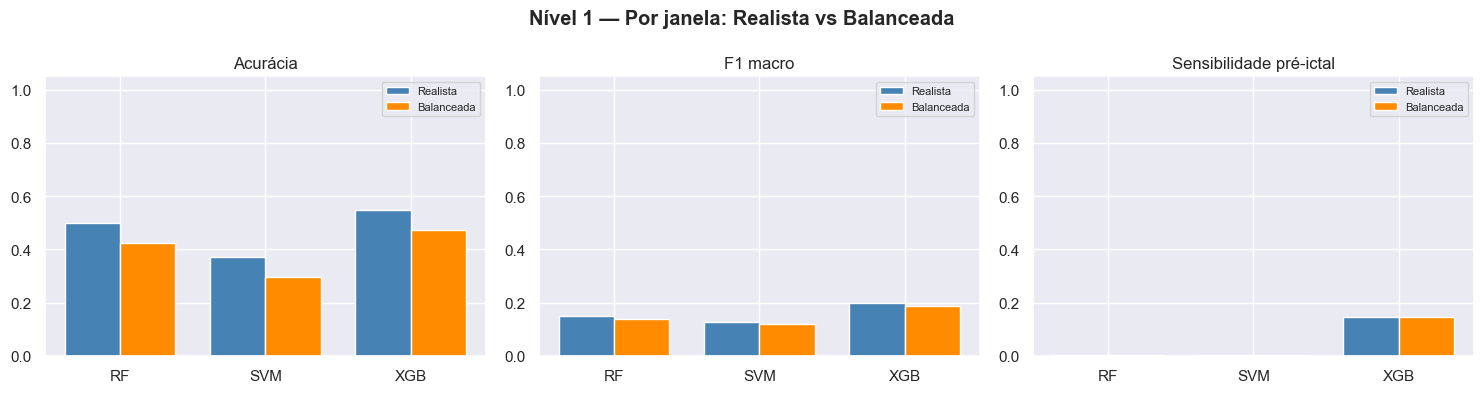

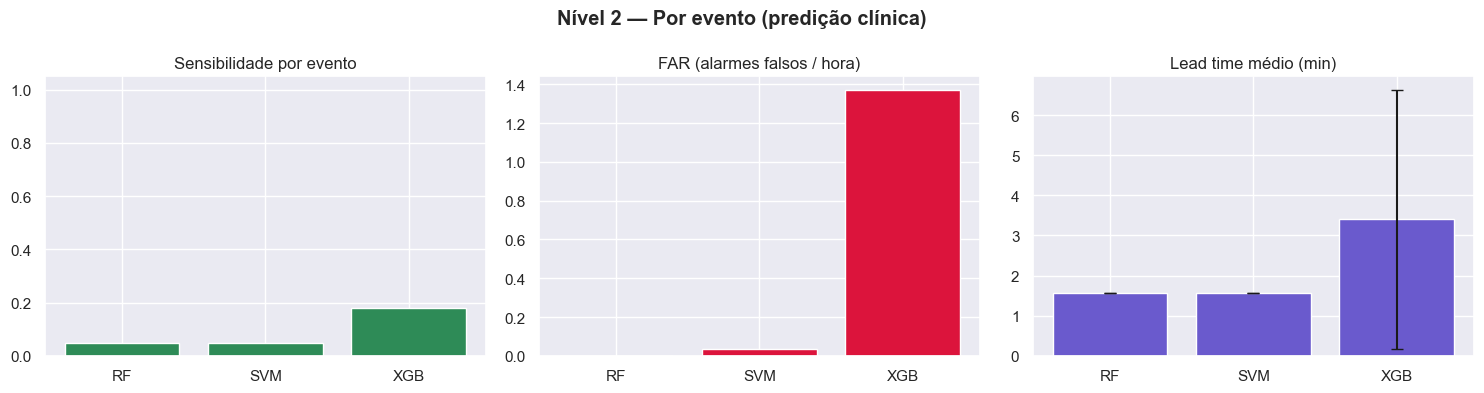

In [48]:
import matplotlib.pyplot as plt

if not df_window.empty:
    # ── Gráfico 1: métricas por janela (Realista vs Balanceada) ─────────────
    win_metrics = [('acc_real','acc_bal','Acurácia'),
                   ('f1macro_real','f1macro_bal','F1 macro'),
                   ('sens_pre_real','sens_pre_bal','Sensibilidade pré-ictal')]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Nível 1 — Por janela: Realista vs Balanceada', fontweight='bold')
    x = np.arange(len(df_window)); w = 0.38
    for ax, (cr, cb, title) in zip(axes, win_metrics):
        ax.bar(x - w/2, df_window[cr], w, label='Realista', color='steelblue')
        ax.bar(x + w/2, df_window[cb], w, label='Balanceada', color='darkorange')
        ax.set_xticks(x); ax.set_xticklabels(df_window['Modelo'])
        ax.set_ylim(0, 1.05); ax.set_title(title); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    # ── Gráfico 2: métricas por evento ──────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Nível 2 — Por evento (predição clínica)', fontweight='bold')
    xe = np.arange(len(df_event))
    axes[0].bar(xe, df_event['event_sens'], color='seagreen')
    axes[0].set_title('Sensibilidade por evento'); axes[0].set_ylim(0, 1.05)
    axes[1].bar(xe, df_event['event_far_h'], color='crimson')
    axes[1].set_title('FAR (alarmes falsos / hora)')
    axes[2].bar(xe, df_event['lead_mean_s'] / 60.0, yerr=df_event['lead_std_s']/60.0,
                capsize=4, color='slateblue')
    axes[2].set_title('Lead time médio (min)')
    for ax in axes:
        ax.set_xticks(xe); ax.set_xticklabels(df_event['Modelo'])
    plt.tight_layout(); plt.show()
else:
    print("⚠️ Sem resultados para plotar.")

## 11.9 Matriz de confusão 4×4 (melhor modelo)

Soma as matrizes de todos os folds do modelo com maior sensibilidade por evento.

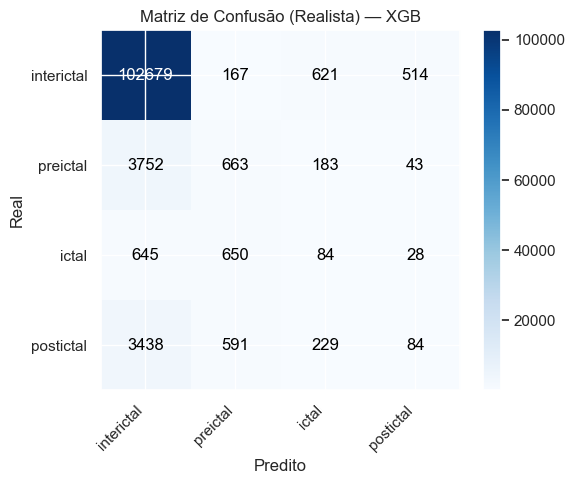

In [49]:
if not df_event.empty:
    best_model = df_event.sort_values('event_sens', ascending=False).iloc[0]['Modelo'].lower()
    res = all_results[best_model]
    cm = np.zeros((len(CLASSES), len(CLASSES)), dtype=int)
    for r in res:
        cm += np.array(r['realista_window']['confusion'])

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(CLASSES))); ax.set_yticks(range(len(CLASSES)))
    ax.set_xticklabels([LBL_NAMES[c] for c in CLASSES], rotation=45, ha='right')
    ax.set_yticklabels([LBL_NAMES[c] for c in CLASSES])
    ax.set_xlabel('Predito'); ax.set_ylabel('Real')
    ax.set_title(f'Matriz de Confusão (Realista) — {best_model.upper()}')
    thr = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > thr else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()

## 11.10 Salvar resultados e sumário final

In [ ]:
# Salva CSVs
df_window.to_csv(os.path.join(ROOT_DIR, 'pred_metrics_window.csv'), index=False)
df_event.to_csv(os.path.join(ROOT_DIR, 'pred_metrics_event.csv'), index=False)

print("="*66)
print("SUMÁRIO FINAL — PREDIÇÃO DE CRISES (multiclasse, LOSO)")
print("="*66)
if not df_event.empty:
    be = df_event.sort_values('event_sens', ascending=False).iloc[0]
    bw = df_window[df_window['Modelo'] == be['Modelo']].iloc[0]
    print(f"\nMelhor modelo (por sensibilidade de evento): {be['Modelo']}  (ratio 1:{RATIO})")
    print("\n── Nível 1 (por janela) ──")
    print(f"   [Realista]   acc={bw['acc_real']:.3f}  F1macro={bw['f1macro_real']:.3f}  "
          f"sens_preictal={bw['sens_pre_real']:.3f}  prec_preictal={bw['prec_pre_real']:.3f}")
    print(f"   [Balanceada] acc={bw['acc_bal']:.3f}  F1macro={bw['f1macro_bal']:.3f}  "
          f"sens_preictal={bw['sens_pre_bal']:.3f}")
    print("\n── Nível 2 (por evento) ──")
    print(f"   Sensibilidade/evento: {be['event_sens']:.3f} "
          f"({int(be['previstas'])}/{int(be['crises'])} crises previstas)")
    print(f"   FAR/hora           : {be['event_far_h']:.2f} alarmes/h")
    if be['n_leads'] > 0:
        print(f"   Lead time médio    : {be['lead_mean_s']:.0f}s ± {be['lead_std_s']:.0f}s "
              f"({be['lead_mean_s']/60:.1f} min) sobre {int(be['n_leads'])} crises previstas")
    else:
        print("   Lead time médio    : — (nenhuma crise prevista)")
print("\n✅ Pipeline de predição concluído")

---
# Resumo e Próximos Passos

## ✅ O que foi implementado

| Etapa | Status |
|-------|--------|
| Download CHB-MIT / Siena / SeizeIT2 (só EDFs com crise) | ✅ |
| Escalável p/ vários pacientes (listas em `PATIENTS`) | ✅ |
| Parsers de anotação (CHB-MIT, Siena, SeizeIT2 sem `impd`) | ✅ |
| EDA (sinal, PSD, tabela comparativa) | ✅ |
| Pré-processamento (notch + passa-banda) | ✅ |
| Rotulagem 4 estados (inter/pré/ictal/pós) | ✅ |
| Janelamento 4 s · 50 % overlap | ✅ |
| Features (temporal + espectral + não-linear) | ✅ |
| **Classificação multiclasse (4 classes)** | ✅ |
| **Predição via votação deslizante (7/10) + refratário** | ✅ |
| **Dupla avaliação: paciente inteiro vs balanceado** | ✅ |
| **Métricas por janela e por evento (sens, FAR, lead time)** | ✅ |

## 🔜 Próximos passos (alinhados ao TCC)
- **Generalização entre datasets** (treinar CHB-MIT → testar Siena, etc.).
- **Simulação vestível**: reduzir canais (19 → 8 → 4 → 2) e medir a perda.
- **Interpretabilidade**: SHAP / Permutation Importance no melhor modelo
  para identificar regiões cerebrais e bandas de frequência discriminativas.
- **Deep Learning**: 1D-CNN, CNN-LSTM, TCN para comparação.

## ▶️ Como escalar
Basta adicionar pacientes às listas em `PATIENTS` (Capítulo 1). Todo o pipeline
— download, parsing, L1/L2, features, LOSO — percorre as listas em loop.
